# Import Library

In [67]:
# Data processing
import pandas as pd
import numpy as np

# Path and file management
import os
from pathlib import Path

# Model saving/loading
import joblib

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning supaya output notebook lebih bersih
import warnings
warnings.filterwarnings("ignore")


import math


## Setup Path Folder

In [46]:
BASE_DIR = Path("..").resolve()

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = RAW_DIR / "smart_grid_security_dataset.csv"

PROCESSED_DATA_PATH = PROCESSED_DIR / "smart_grid_security_processed.csv"

SCALER_PATH = MODELS_DIR / "scaler.pkl"
FEATURE_COLUMNS_PATH = MODELS_DIR / "feature_columns.pkl"
ENSEMBLE_MODEL_PATH = MODELS_DIR / "ensemble_model.pkl"
MODEL_METADATA_PATH = MODELS_DIR / "model_metadata.pkl"

PREDICTION_RESULT_PATH = OUTPUTS_DIR / "prediction_result.csv"
PREDICTION_SUMMARY_PATH = OUTPUTS_DIR / "prediction_summary.txt"

print("Setup path berhasil.")
print("BASE_DIR       :", BASE_DIR)
print("RAW_DIR        :", RAW_DIR)
print("PROCESSED_DIR  :", PROCESSED_DIR)
print("MODELS_DIR     :", MODELS_DIR)
print("OUTPUTS_DIR    :", OUTPUTS_DIR)
print("DATASET_PATH   :", DATASET_PATH)

Setup path berhasil.
BASE_DIR       : E:\project-kda-kelompok3
RAW_DIR        : E:\project-kda-kelompok3\data\raw
PROCESSED_DIR  : E:\project-kda-kelompok3\data\processed
MODELS_DIR     : E:\project-kda-kelompok3\models
OUTPUTS_DIR    : E:\project-kda-kelompok3\outputs
DATASET_PATH   : E:\project-kda-kelompok3\data\raw\smart_grid_security_dataset.csv


# Load Dataset

In [47]:
# Load dataset utama dari folder data/raw
data = pd.read_csv(DATASET_PATH)

print("Dataset berhasil dimuat.")
print("Path dataset :", DATASET_PATH)
print("Shape dataset:", data.shape)

display(data.head())

Dataset berhasil dimuat.
Path dataset : E:\project-kda-kelompok3\data\raw\smart_grid_security_dataset.csv
Shape dataset: (10000, 14)


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
0,2024-01-01 11:42:30,SGD-0019,362.7721,4.8409,543.9913,51.0723,68.2365,650.3120,64.0091,34.7634,2.0,0,5,1
1,2024-01-01 09:49:05,SGD-0036,219.9191,5.2442,1095.6327,50.0000,30.0000,208.4703,15.6947,36.2824,27.0,1,2,1
2,2024-01-01 06:57:50,SGD-0037,219.6843,6.5328,1363.3934,49.9166,27.3897,20.8755,0.3336,93.3756,1.0,1,0,0
3,2024-01-01 02:03:35,SGD-0047,217.1400,4.7727,984.5324,49.8375,39.9490,22.3209,1.4493,97.4572,0.0,1,0,0
4,2024-01-01 05:08:00,SGD-0023,219.5477,5.0714,1057.7341,50.1409,32.7594,28.3325,1.2772,91.4877,0.0,1,0,0


In [48]:
# Cek apakah dataset kosong
if data.empty:
    print("Dataset kosong. Periksa kembali file CSV.")
else:
    print("Dataset tidak kosong dan siap digunakan.")

# Cek jumlah baris dan kolom
total_rows, total_columns = data.shape

print("\nInformasi ukuran dataset:")
print("Total baris :", total_rows)
print("Total kolom :", total_columns)

Dataset tidak kosong dan siap digunakan.

Informasi ukuran dataset:
Total baris : 10000
Total kolom : 14


In [49]:
print("Daftar kolom dataset:")
print(data.columns.tolist())

Daftar kolom dataset:
['timestamp', 'device_id', 'voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail', 'label']


In [51]:
required_columns = [
    "timestamp",
    "device_id",
    "voltage",
    "current",
    "power",
    "frequency",
    "temperature",
    "latency",
    "packet_loss",
    "throughput",
    "duplicate_packet",
    "checksum_valid",
    "authentication_fail",
    "label"
]

missing_columns = [col for col in required_columns if col not in data.columns]

if len(missing_columns) == 0:
    print("Semua kolom wajib tersedia.")
else:
    print("Ada kolom wajib yang tidak ditemukan:")
    print(missing_columns)

Semua kolom wajib tersedia.


In [52]:
label_mapping = {
    0: "normal",
    1: "attack",
    2: "fault"
}

print("Nilai unik pada kolom label:")
print(data["label"].unique())

print("\nDistribusi label:")
print(data["label"].value_counts().sort_index())

print("\nDistribusi label dengan keterangan:")
print(
    data["label"]
    .value_counts()
    .sort_index()
    .rename(index=label_mapping)
)

Nilai unik pada kolom label:
[1 0 2]

Distribusi label:
label
0    6000
1    2500
2    1500
Name: count, dtype: int64

Distribusi label dengan keterangan:
label
normal    6000
attack    2500
fault     1500
Name: count, dtype: int64


# Exploratory Data Analysis

In [69]:
print("Shape dataset:")
print(data.shape)

print("\nDaftar kolom dataset:")
print(data.columns.tolist())

print("\nInformasi tipe data:")
data.info()

Shape dataset:
(10000, 14)

Daftar kolom dataset:
['timestamp', 'device_id', 'voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail', 'label']

Informasi tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            10000 non-null  str    
 1   device_id            10000 non-null  str    
 2   voltage              9950 non-null   float64
 3   current              9957 non-null   float64
 4   power                9910 non-null   float64
 5   frequency            10000 non-null  float64
 6   temperature          9935 non-null   float64
 7   latency              10000 non-null  float64
 8   packet_loss          10000 non-null  float64
 9   throughput           10000 non-null  float64
 10  duplicate_packet     10000 non

In [70]:
print("5 data pertama:")
display(data.head())

print("5 data terakhir:")
display(data.tail())

5 data pertama:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
0,2024-01-01 11:42:30,SGD-0019,362.7721,4.8409,543.9913,51.0723,68.2365,650.3120,64.0091,34.7634,2.0,0,5,1
1,2024-01-01 09:49:05,SGD-0036,219.9191,5.2442,1095.6327,50.0000,30.0000,208.4703,15.6947,36.2824,27.0,1,2,1
2,2024-01-01 06:57:50,SGD-0037,219.6843,6.5328,1363.3934,49.9166,27.3897,20.8755,0.3336,93.3756,1.0,1,0,0
3,2024-01-01 02:03:35,SGD-0047,217.1400,4.7727,984.5324,49.8375,39.9490,22.3209,1.4493,97.4572,0.0,1,0,0
4,2024-01-01 05:08:00,SGD-0023,219.5477,5.0714,1057.7341,50.1409,32.7594,28.3325,1.2772,91.4877,0.0,1,0,0


5 data terakhir:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
9995,2024-01-01 11:04:10,SGD-0037,385.6119,19.2339,3481.0482,62.1148,39.9854,747.3052,68.2331,48.9258,18.0,0,0,1
9996,2024-01-01 09:46:00,SGD-0009,216.5006,6.2260,1280.5316,50.0000,30.0000,456.8462,21.5670,34.3756,11.0,1,5,1
9997,2024-01-01 13:16:15,SGD-0045,247.1631,6.0876,1589.4411,50.1204,52.6203,76.6473,1.8116,53.8487,5.0,1,0,2
9998,2024-01-01 02:13:25,SGD-0017,219.7143,4.9151,1025.9213,49.8794,25.8776,20.2265,0.1867,98.7012,2.0,1,0,0
9999,2024-01-01 09:03:10,SGD-0023,324.4927,15.3910,5828.2880,51.3413,60.9986,224.2764,12.4473,12.8483,0.0,0,0,1


In [71]:
total_rows, total_columns = data.shape

print("Jumlah baris :", total_rows)
print("Jumlah kolom :", total_columns)

Jumlah baris : 10000
Jumlah kolom : 14


In [72]:
missing_count = data.isnull().sum()
missing_percentage = (missing_count / len(data) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

print("Ringkasan missing value:")
display(missing_summary)

print("Kolom yang memiliki missing value:")
display(missing_summary[missing_summary["missing_count"] > 0])

Ringkasan missing value:


,missing_count,missing_percentage
timestamp,0,0.00
device_id,0,0.00
voltage,50,0.50
current,43,0.43
power,90,0.90
frequency,0,0.00
temperature,65,0.65
latency,0,0.00
packet_loss,0,0.00
throughput,0,0.00


Kolom yang memiliki missing value:


,missing_count,missing_percentage
voltage,50,0.50
current,43,0.43
power,90,0.90
temperature,65,0.65


In [73]:
duplicate_count = data.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

if duplicate_count > 0:
    print("Contoh data duplikat:")
    display(data[data.duplicated()].head())
else:
    print("Tidak ada data duplikat.")

Jumlah data duplikat: 0
Tidak ada data duplikat.


In [74]:
print("Statistik deskriptif fitur numerik:")
display(data.describe())

Statistik deskriptif fitur numerik:


,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
count,9950.000000,9957.000000,9910.000000,10000.000000,9935.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,223.355752,7.502727,1418.336060,50.202664,38.156669,114.638387,11.171086,76.540476,4.675700,0.906000,1.177700,0.550000
std,39.989603,6.708374,1073.742775,2.120315,13.994164,201.208380,19.011050,29.387440,8.607226,0.291843,2.601999,0.739969
min,100.014300,0.037000,-496.271900,40.024300,10.296100,5.002800,0.000000,1.002500,0.000000,0.000000,0.000000,0.000000
25%,217.789400,4.927400,1023.549850,49.887700,30.000000,14.203450,0.772025,61.439725,0.000000,1.000000,0.000000,0.000000
50%,219.919100,5.634100,1170.818800,50.000000,34.099300,23.159350,1.545800,92.161450,1.000000,1.000000,0.000000,0.000000
75%,221.910800,6.663000,1385.476975,50.124425,39.237150,76.789775,10.220975,95.972050,3.000000,1.000000,1.000000,1.000000
max,399.961700,49.897400,14622.300100,64.963100,99.956500,999.826600,79.992700,99.999800,49.000000,1.000000,14.000000,2.000000


In [75]:
label_mapping = {
    0: "normal",
    1: "attack",
    2: "fault"
}

label_counts = data["label"].value_counts().sort_index()
label_percentages = (label_counts / label_counts.sum() * 100).round(2)

label_summary = pd.DataFrame({
    "label": label_counts.index,
    "class_name": label_counts.index.map(label_mapping),
    "count": label_counts.values,
    "percentage": label_percentages.values
})

print("Distribusi label:")
display(label_summary)

Distribusi label:


,label,class_name,count,percentage
0,0,normal,6000,60.0
1,1,attack,2500,25.0
2,2,fault,1500,15.0


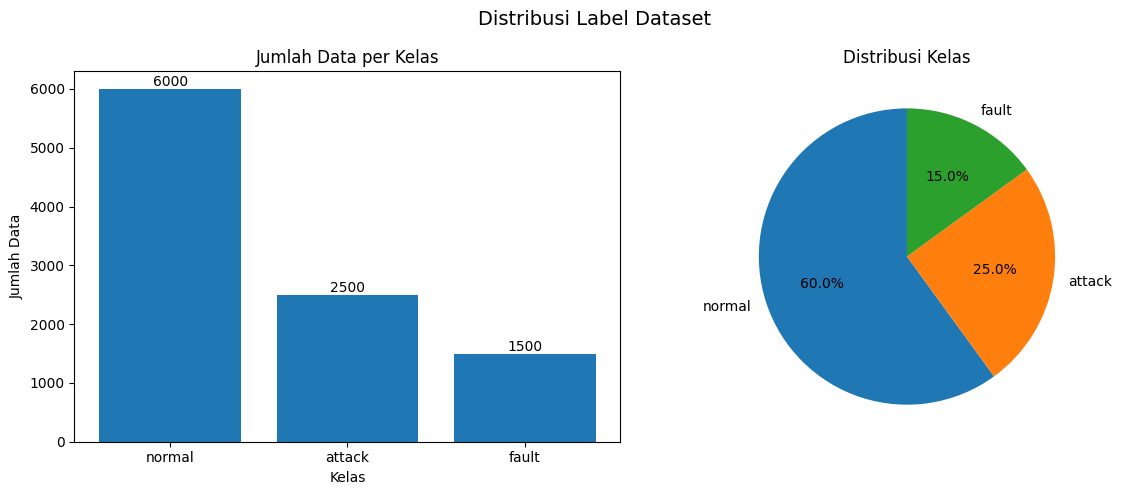

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart jumlah data per kelas
axes[0].bar(
    label_summary["class_name"],
    label_summary["count"]
)

axes[0].set_title("Jumlah Data per Kelas")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Data")

for index, value in enumerate(label_summary["count"]):
    axes[0].text(
        index,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

# Pie chart distribusi kelas
axes[1].pie(
    label_summary["count"],
    labels=label_summary["class_name"],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Distribusi Kelas")

plt.suptitle("Distribusi Label Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [77]:
categorical_columns = ["timestamp", "device_id"]

print("Kolom kategorikal/non-numerik:")
print(categorical_columns)

print("\nJumlah device_id unik:")
print(data["device_id"].nunique())

print("\nContoh device_id:")
print(data["device_id"].unique()[:10])

Kolom kategorikal/non-numerik:
['timestamp', 'device_id']

Jumlah device_id unik:
50

Contoh device_id:
<ArrowStringArray>
['SGD-0019', 'SGD-0036', 'SGD-0037', 'SGD-0047', 'SGD-0023', 'SGD-0035',
 'SGD-0048', 'SGD-0006', 'SGD-0026', 'SGD-0008']
Length: 10, dtype: str


In [78]:
numeric_feature_columns = [
    "voltage",
    "current",
    "power",
    "frequency",
    "temperature",
    "latency",
    "packet_loss",
    "throughput",
    "duplicate_packet",
    "checksum_valid",
    "authentication_fail"
]

target_column = "label"

print("Fitur numerik yang akan dianalisis:")
print(numeric_feature_columns)

print("\nTarget:")
print(target_column)

Fitur numerik yang akan dianalisis:
['voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail']

Target:
label


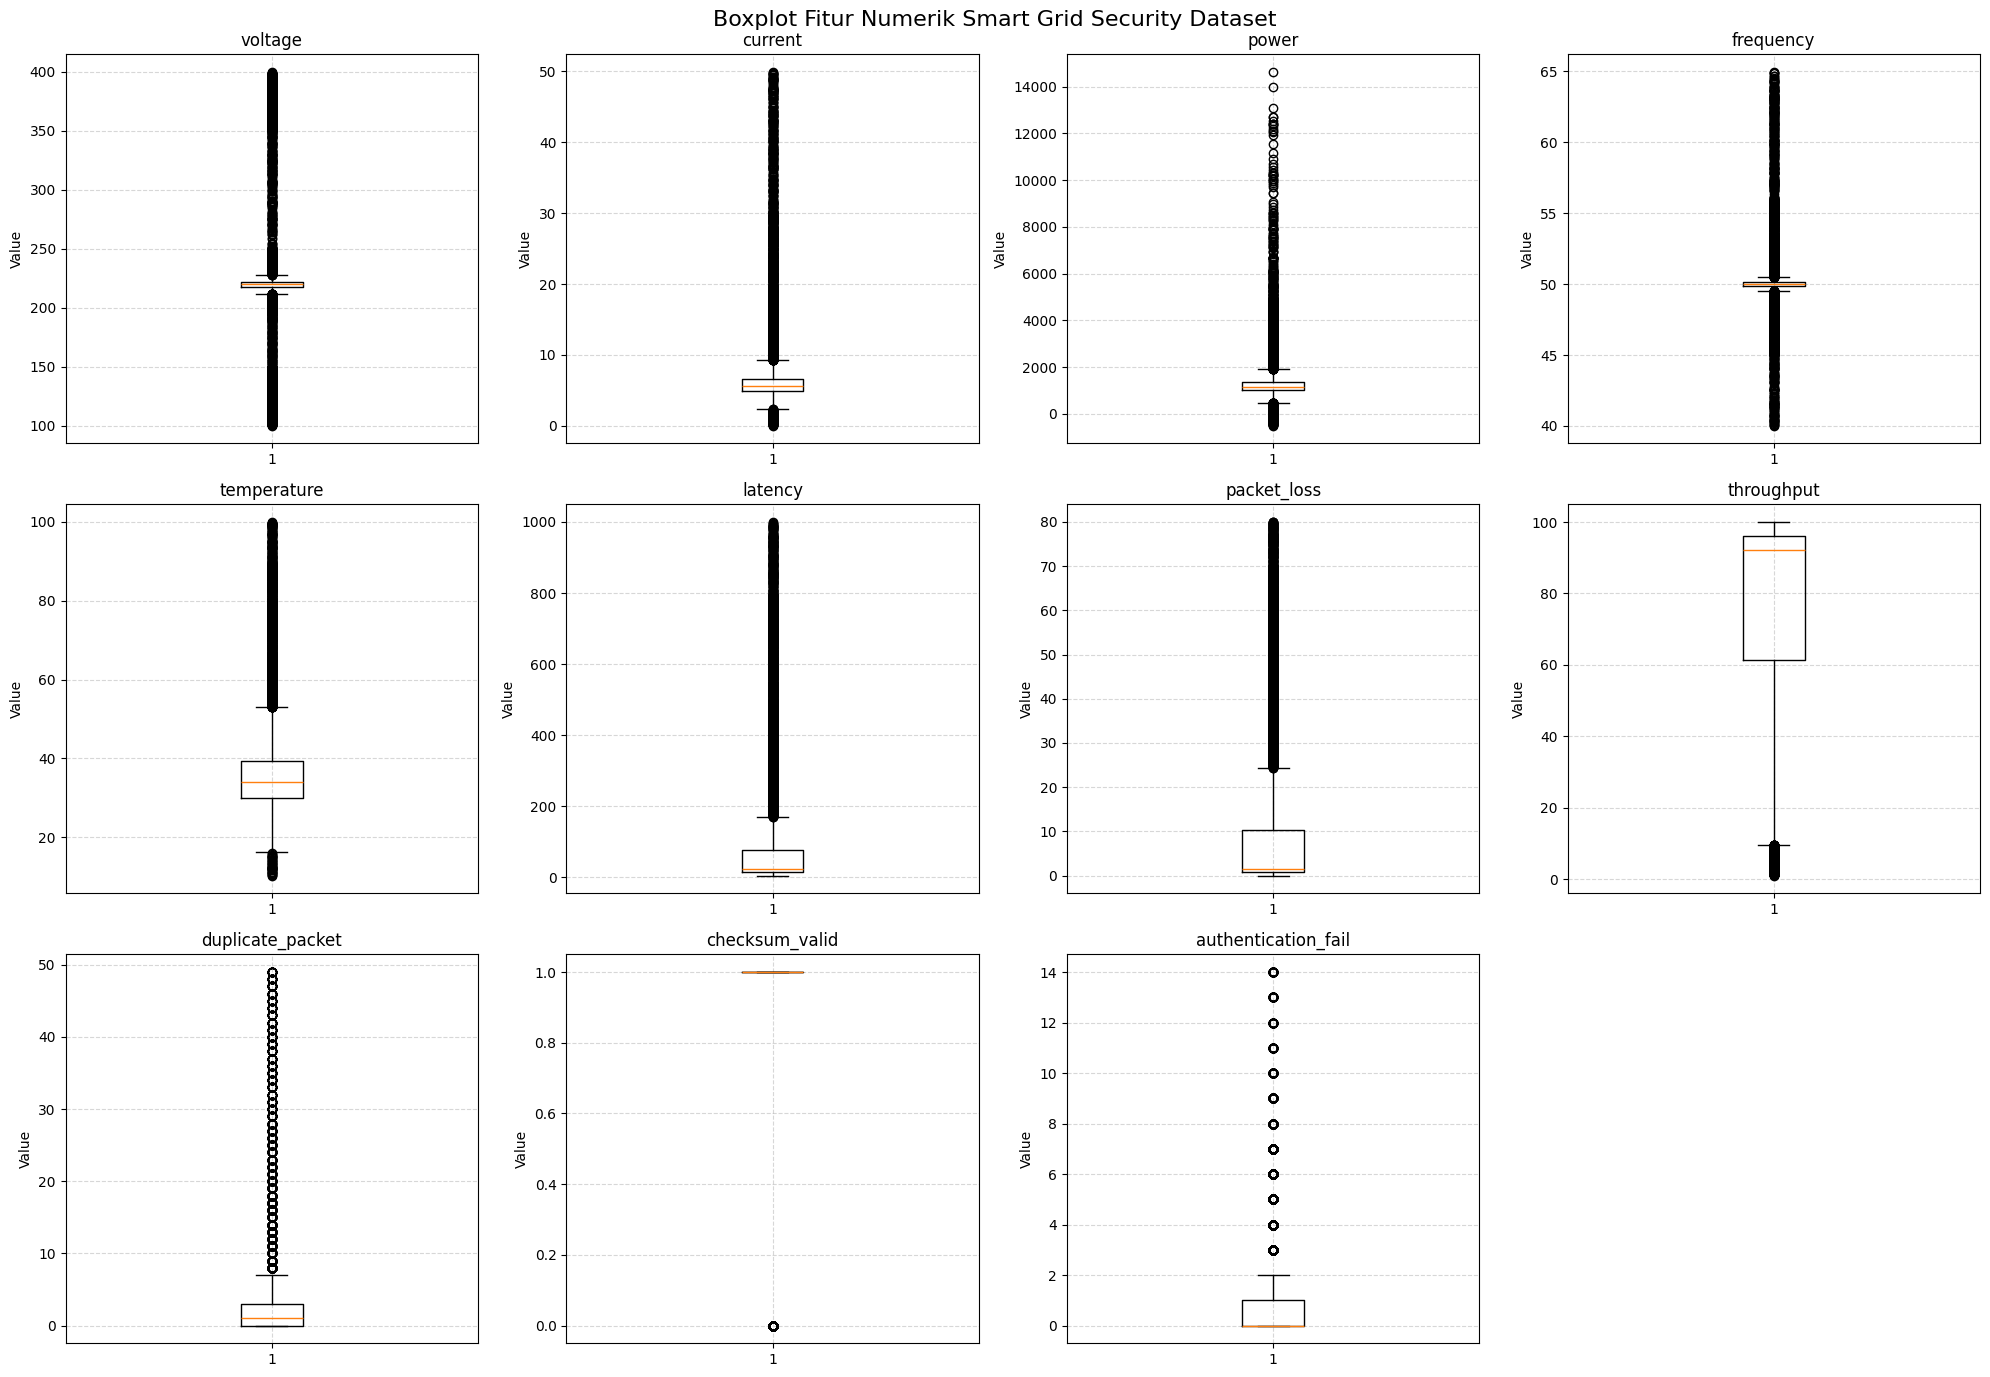

In [ ]:
num_features = len(numeric_feature_columns)

n_cols = 4
n_rows = math.ceil(num_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 14)
)

axes = axes.flatten()

for i, col in enumerate(numeric_feature_columns):
    axes[i].boxplot(
        data[col].dropna(),
        vert=True
    )
    
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Boxplot Fitur Numerik Smart Grid Security Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

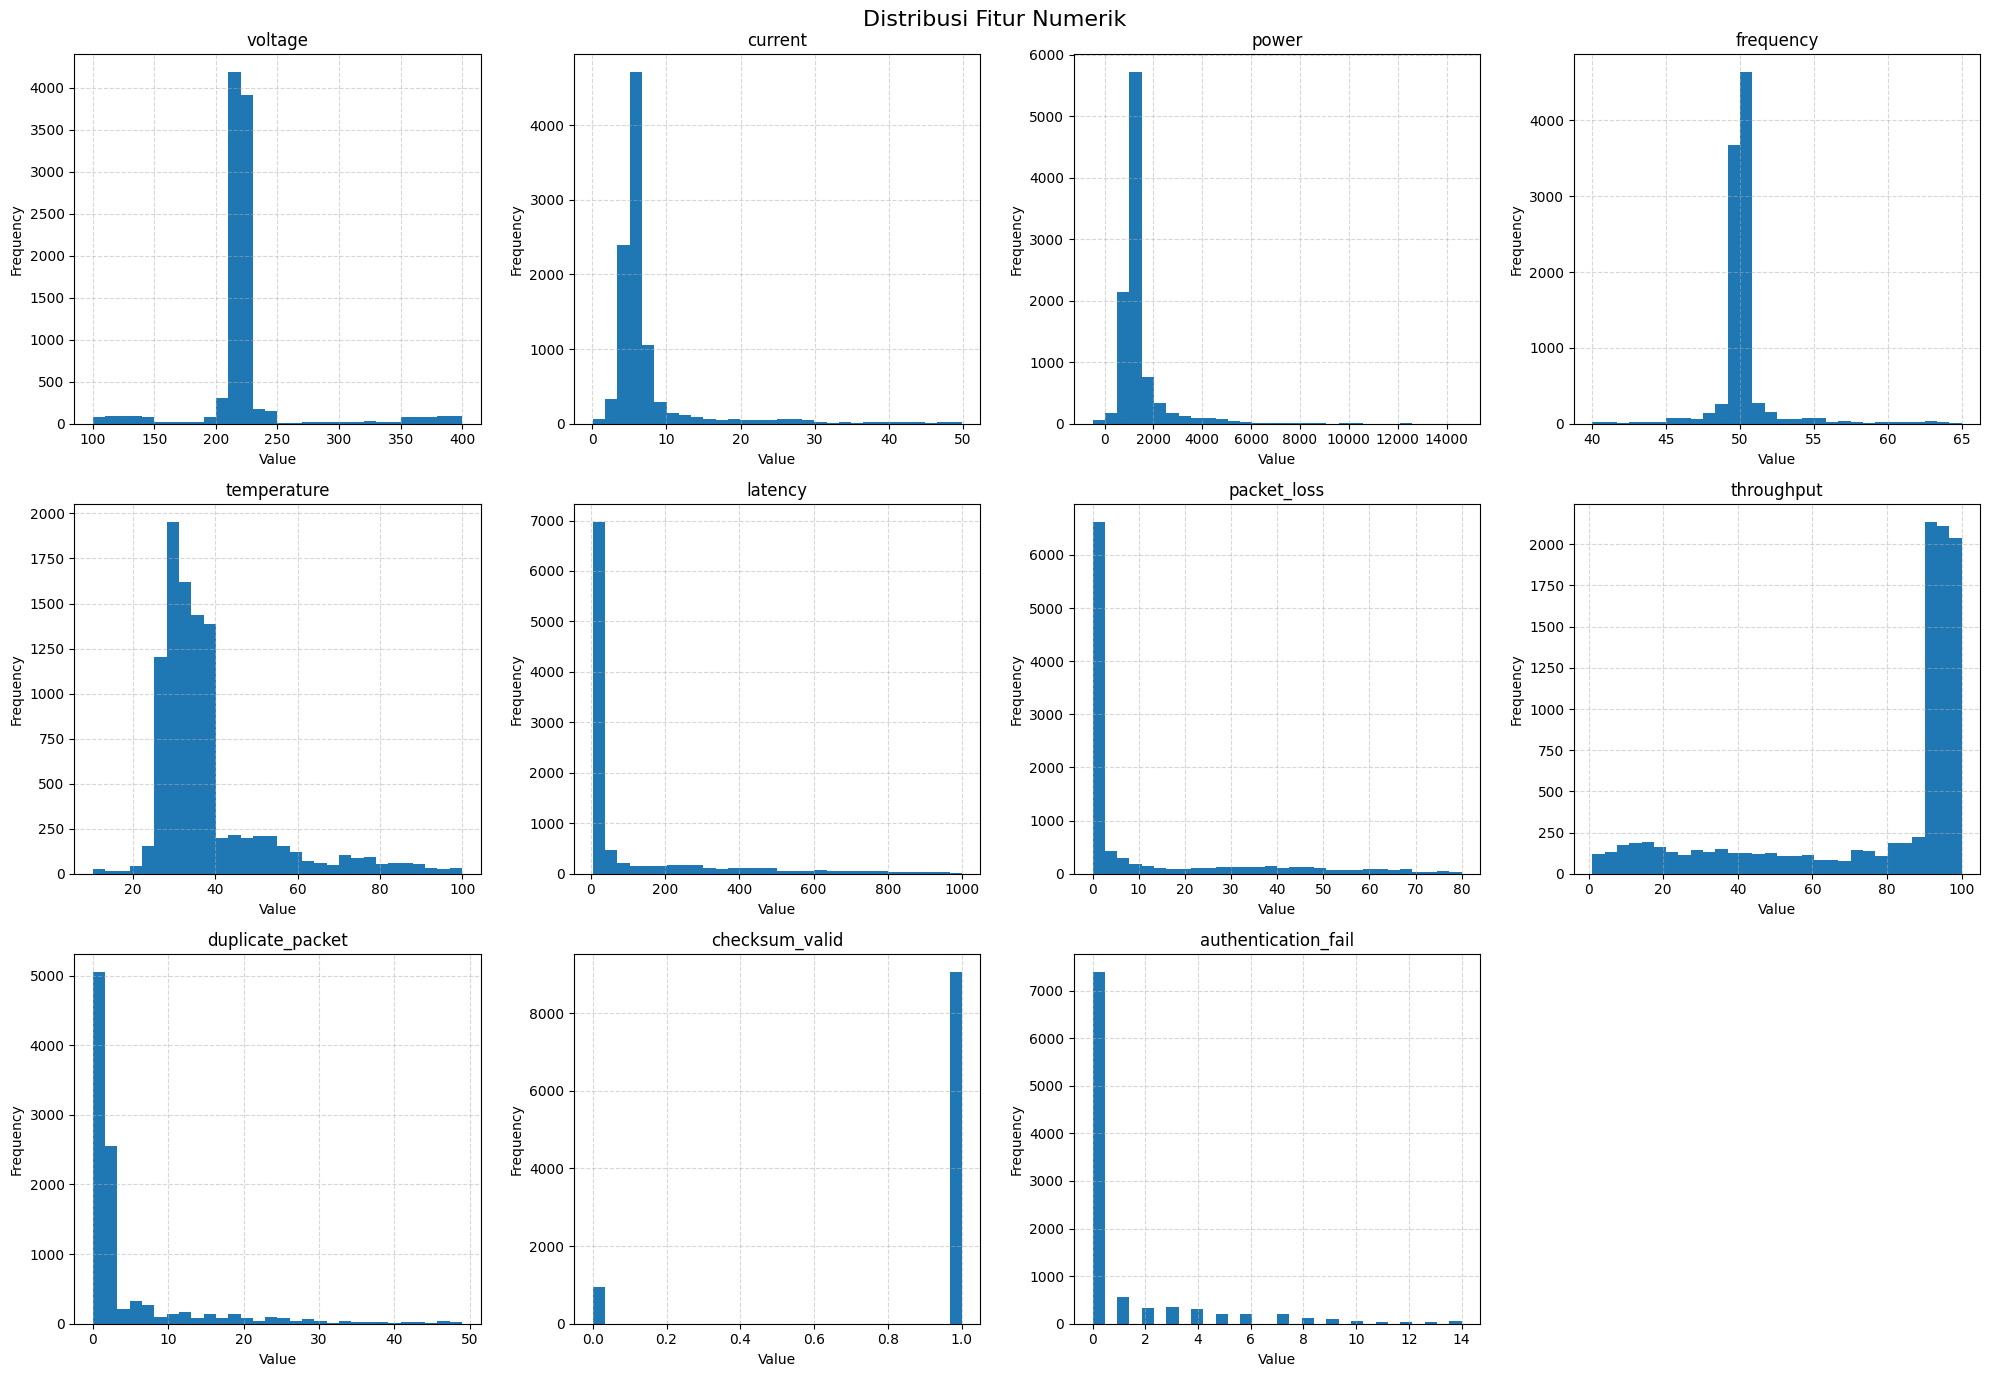

In [ ]:
num_features = len(numeric_feature_columns)

n_cols = 4
n_rows = math.ceil(num_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 14)
)

axes = axes.flatten()

for i, col in enumerate(numeric_feature_columns):
    axes[i].hist(
        data[col].dropna(),
        bins=30
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribusi Fitur Numerik",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [83]:
correlation_columns = numeric_feature_columns + ["label"]

correlation_matrix = data[correlation_columns].corr()

display(correlation_matrix)

,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
voltage,1.000000,0.139517,0.287452,0.055200,0.078469,0.070980,0.086245,-0.101249,-0.005320,-0.122756,0.050451,0.061832
current,0.139517,1.000000,0.491456,0.215272,0.317833,0.348932,0.382044,-0.429061,0.132017,-0.415382,0.263034,0.220229
power,0.287452,0.491456,1.000000,0.106295,0.289681,0.177048,0.215148,-0.301712,0.061169,-0.262534,0.149801,0.214222
frequency,0.055200,0.215272,0.106295,1.000000,0.094659,0.147179,0.166708,-0.159098,0.067291,-0.159712,0.097251,0.057084
temperature,0.078469,0.317833,0.289681,0.094659,1.000000,0.229716,0.273118,-0.344914,0.133266,-0.258588,0.197757,0.494083
latency,0.070980,0.348932,0.177048,0.147179,0.229716,1.000000,0.863182,-0.842101,0.785125,-0.531675,0.788454,0.311667
packet_loss,0.086245,0.382044,0.215148,0.166708,0.273118,0.863182,1.000000,-0.891788,0.793216,-0.558446,0.803800,0.359824
throughput,-0.101249,-0.429061,-0.301712,-0.159098,-0.344914,-0.842101,-0.891788,1.000000,-0.760444,0.557095,-0.783574,-0.476659
duplicate_packet,-0.005320,0.132017,0.061169,0.067291,0.133266,0.785125,0.793216,-0.760444,1.000000,-0.397611,0.755551,0.274174
checksum_valid,-0.122756,-0.415382,-0.262534,-0.159712,-0.258588,-0.531675,-0.558446,0.557095,-0.397611,1.000000,-0.465292,-0.195894


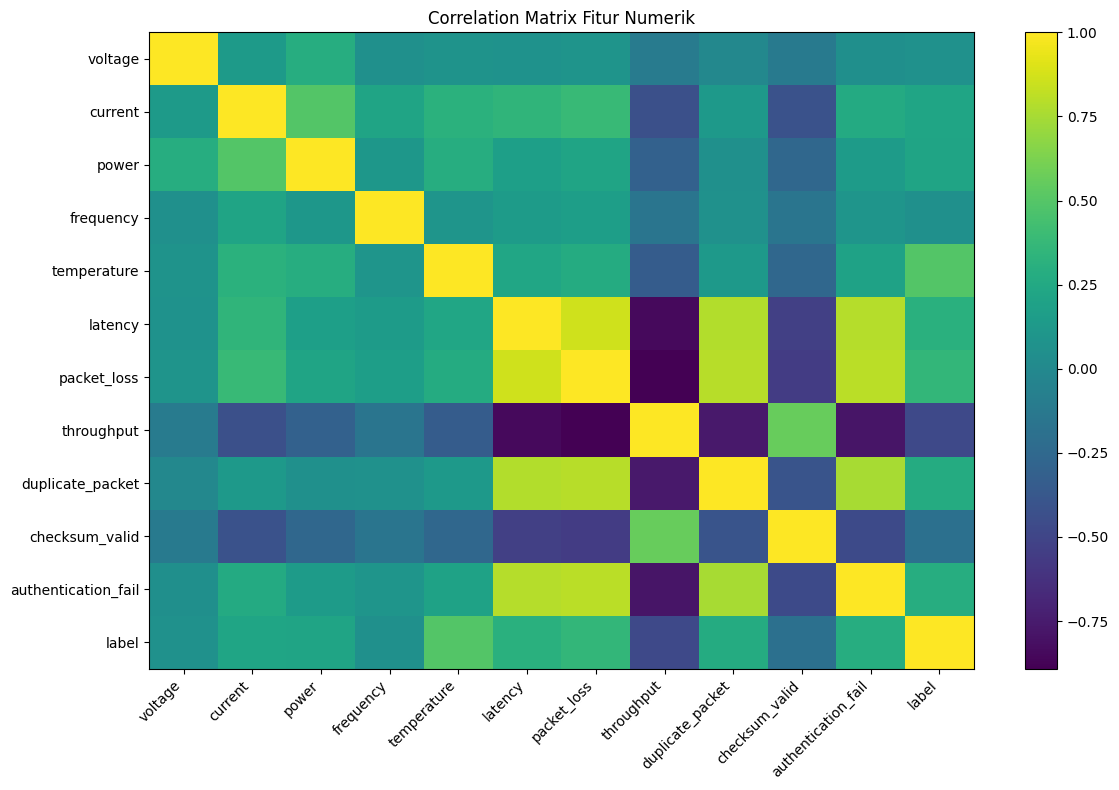

In [84]:
plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix Fitur Numerik")
plt.tight_layout()
plt.show()

In [85]:
# ============================================================
# 4.17 RATA-RATA FITUR BERDASARKAN LABEL
# ============================================================

mean_by_label = data.groupby("label")[numeric_feature_columns].mean()

mean_by_label = mean_by_label.rename(index=label_mapping)

display(mean_by_label)

,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail
label,,,,,,,,,,,
normal,219.973301,5.477180,1144.596082,50.000551,32.681459,17.308425,0.997542,94.995918,0.987667,1.000,0.0000
attack,232.362630,12.898682,2066.519819,50.814594,44.298779,396.227067,39.758683,29.411515,15.394000,0.624,4.5944
fault,221.823000,6.585362,1433.925049,49.991236,50.348990,34.643765,4.219269,81.266980,1.564000,1.000,0.1940


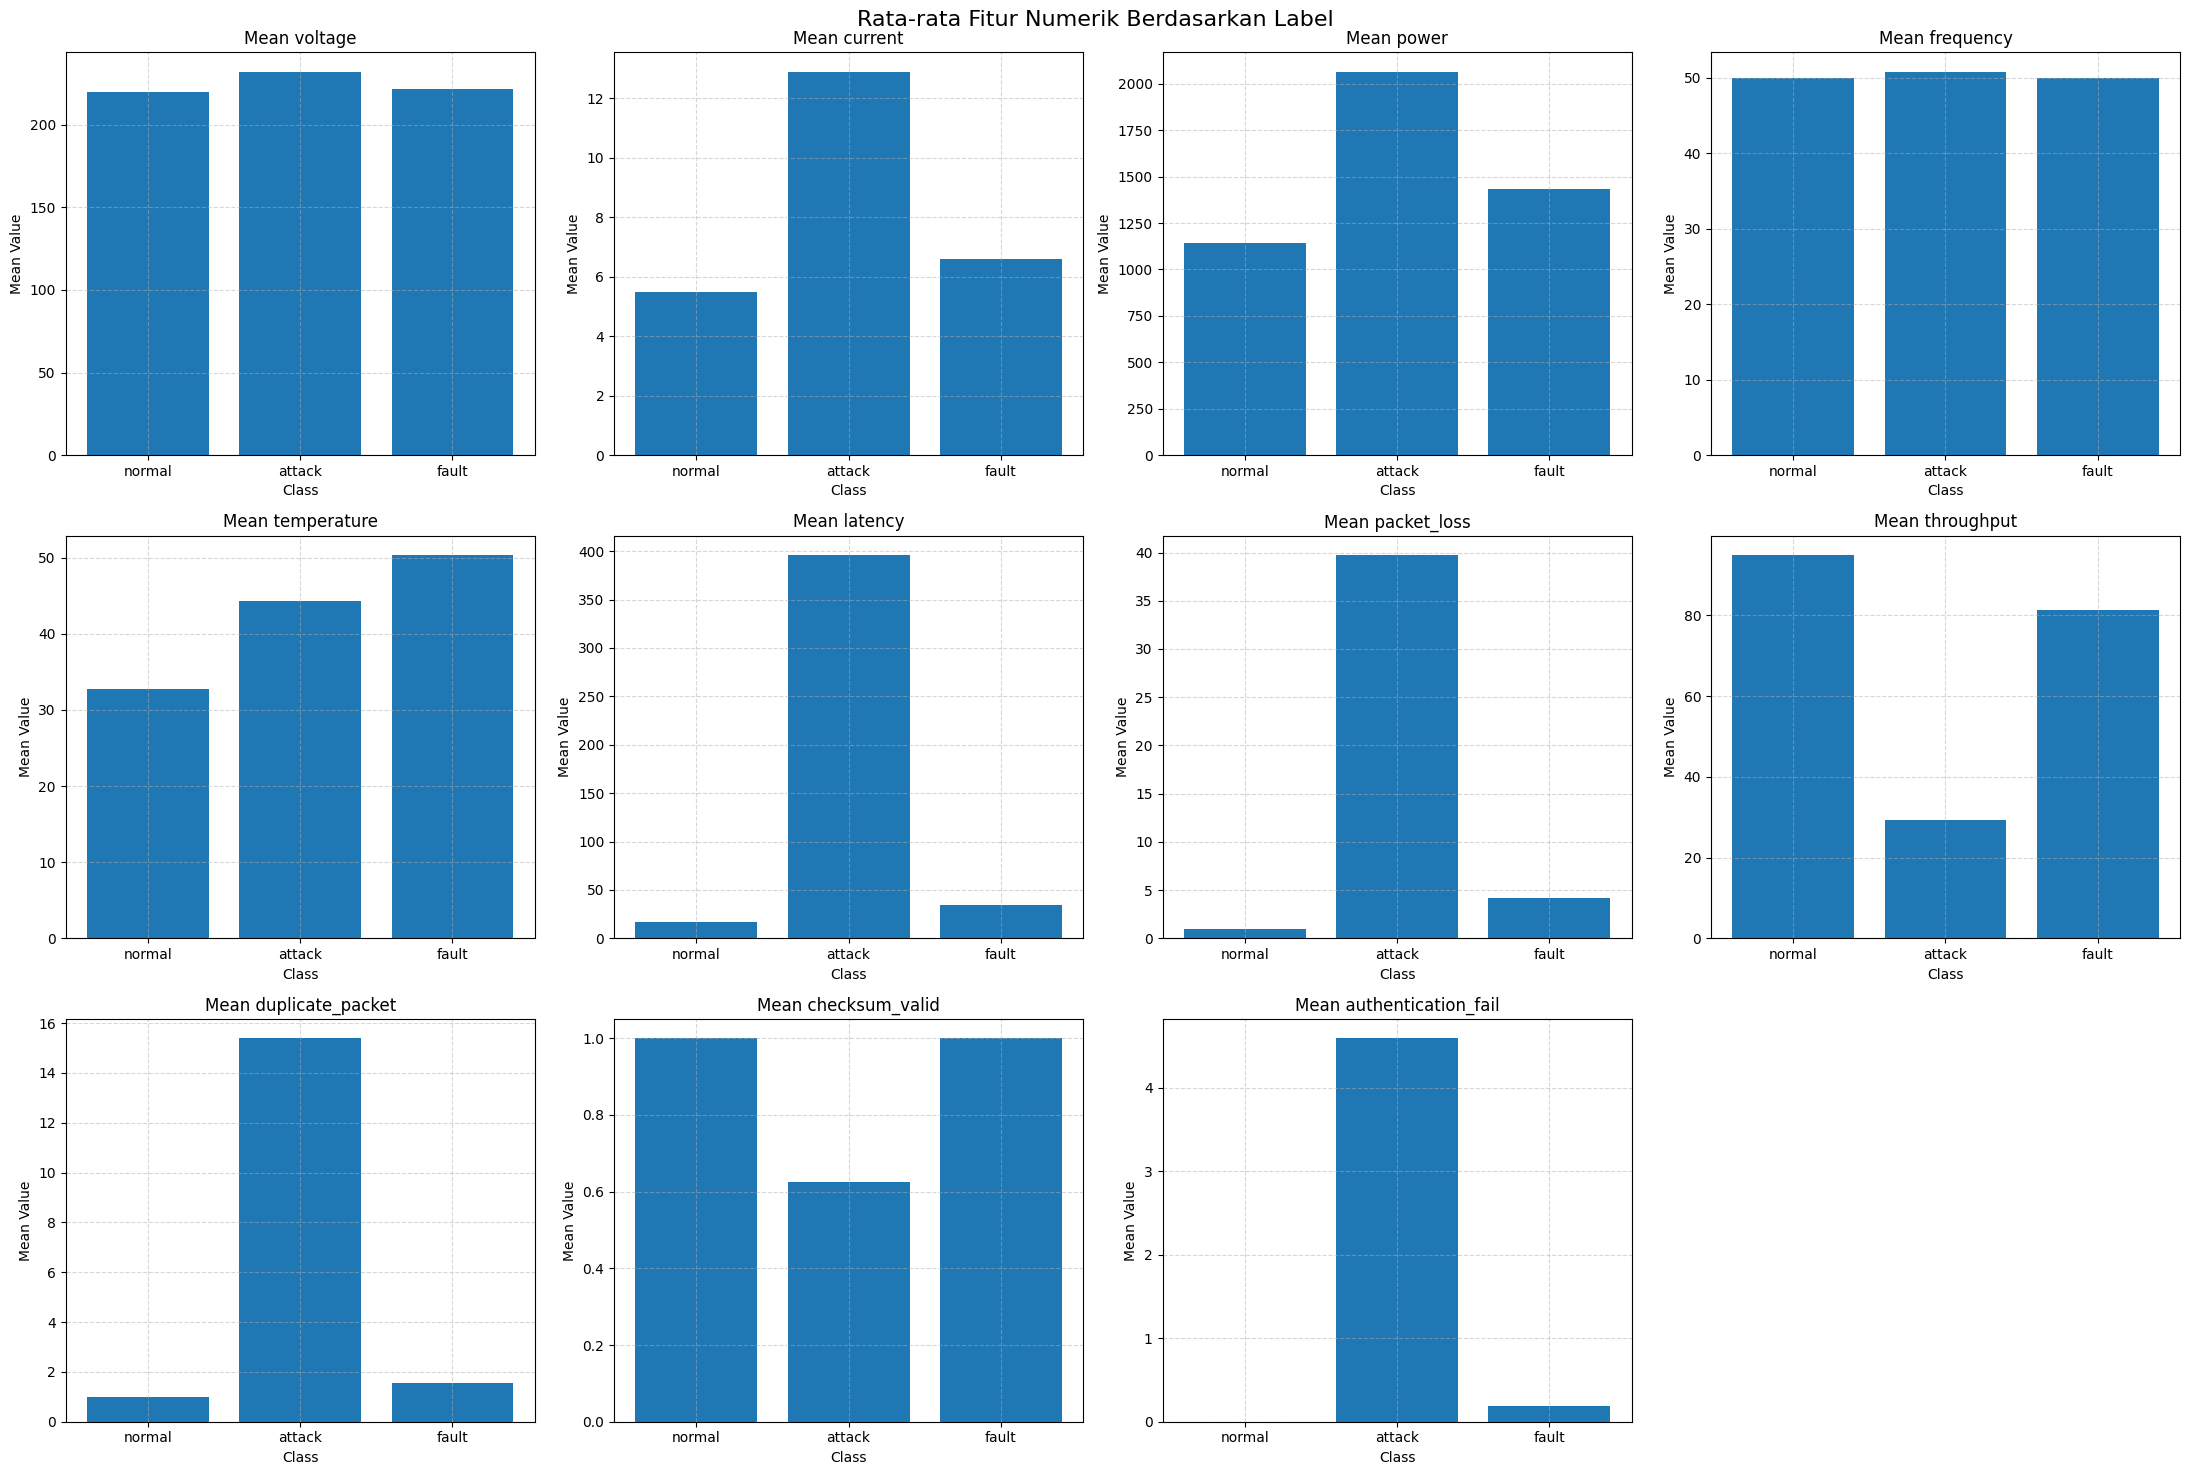

In [86]:
# ============================================================
# 4.18 VISUALISASI RATA-RATA FITUR BERDASARKAN LABEL
# ============================================================

num_features = len(numeric_feature_columns)

n_cols = 4
n_rows = math.ceil(num_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 15)
)

axes = axes.flatten()

for i, col in enumerate(numeric_feature_columns):
    axes[i].bar(
        mean_by_label.index,
        mean_by_label[col]
    )
    
    axes[i].set_title(f"Mean {col}")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Mean Value")
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Rata-rata Fitur Numerik Berdasarkan Label",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
outlier_summary = []

for col in numeric_feature_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = data[
        (data[col] < lower_bound) |
        (data[col] > upper_bound)
    ].shape[0]
    
    outlier_summary.append({
        "feature": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": round(outlier_count / len(data) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
0,voltage,211.607300,228.092900,2008,20.08
1,current,2.324000,9.266400,1350,13.50
2,power,480.659162,1928.367663,1364,13.64
3,frequency,49.532612,50.479512,1939,19.39
4,temperature,16.144275,53.092875,1225,12.25
5,latency,-79.676037,170.669262,2046,20.46
6,packet_loss,-13.401400,24.394400,1910,19.10
7,throughput,9.641238,147.770537,361,3.61
8,duplicate_packet,-4.500000,7.500000,1706,17.06
9,checksum_valid,1.000000,1.000000,940,9.40


# Processing

## Data Cleaning

In [88]:
print("Shape data sebelum cleaning:", data.shape)

print("\n5 data pertama:")
display(data.head())

print("\nInformasi tipe data:")
data.info()

Shape data sebelum cleaning: (10000, 14)

5 data pertama:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
0,2024-01-01 11:42:30,SGD-0019,362.7721,4.8409,543.9913,51.0723,68.2365,650.3120,64.0091,34.7634,2.0,0,5,1
1,2024-01-01 09:49:05,SGD-0036,219.9191,5.2442,1095.6327,50.0000,30.0000,208.4703,15.6947,36.2824,27.0,1,2,1
2,2024-01-01 06:57:50,SGD-0037,219.6843,6.5328,1363.3934,49.9166,27.3897,20.8755,0.3336,93.3756,1.0,1,0,0
3,2024-01-01 02:03:35,SGD-0047,217.1400,4.7727,984.5324,49.8375,39.9490,22.3209,1.4493,97.4572,0.0,1,0,0
4,2024-01-01 05:08:00,SGD-0023,219.5477,5.0714,1057.7341,50.1409,32.7594,28.3325,1.2772,91.4877,0.0,1,0,0



Informasi tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            10000 non-null  str    
 1   device_id            10000 non-null  str    
 2   voltage              9950 non-null   float64
 3   current              9957 non-null   float64
 4   power                9910 non-null   float64
 5   frequency            10000 non-null  float64
 6   temperature          9935 non-null   float64
 7   latency              10000 non-null  float64
 8   packet_loss          10000 non-null  float64
 9   throughput           10000 non-null  float64
 10  duplicate_packet     10000 non-null  float64
 11  checksum_valid       10000 non-null  int64  
 12  authentication_fail  10000 non-null  int64  
 13  label                10000 non-null  int64  
dtypes: float64(9), int64(3), str(2)
memory usage: 1.3 MB


In [89]:
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percentage
})

print("Ringkasan missing value:")
display(missing_summary)

print("\nKolom yang memiliki missing value:")
display(missing_summary[missing_summary["missing_count"] > 0])

Ringkasan missing value:


,missing_count,missing_percentage
timestamp,0,0.00
device_id,0,0.00
voltage,50,0.50
current,43,0.43
power,90,0.90
frequency,0,0.00
temperature,65,0.65
latency,0,0.00
packet_loss,0,0.00
throughput,0,0.00



Kolom yang memiliki missing value:


,missing_count,missing_percentage
voltage,50,0.50
current,43,0.43
power,90,0.90
temperature,65,0.65


In [90]:
rows_with_missing = data[data.isnull().any(axis=1)]

print("Jumlah baris yang memiliki missing value:", rows_with_missing.shape[0])

if rows_with_missing.shape[0] > 0:
    display(rows_with_missing.head())
else:
    print("Tidak ada baris dengan missing value.")

Jumlah baris yang memiliki missing value: 134


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
94,2024-01-01 13:45:45,SGD-0011,NaN,4.3612,NaN,49.9962,46.7105,10.3534,6.5304,75.4264,0.0,1,0,2
132,2024-01-01 13:31:45,SGD-0007,NaN,7.2066,NaN,49.8814,26.1430,26.6519,4.2630,96.1512,2.0,1,0,2
360,2024-01-01 13:45:10,SGD-0014,NaN,3.6188,NaN,50.0842,27.6816,30.3625,5.8875,70.5082,1.0,1,0,2
368,2024-01-01 13:50:50,SGD-0014,218.5666,NaN,NaN,50.0419,30.5884,28.2161,2.6787,98.8743,0.0,1,0,2
491,2024-01-01 13:34:35,SGD-0013,224.7646,NaN,NaN,50.0695,53.7372,14.7964,2.8949,95.0409,2.0,1,0,2


In [91]:
duplicate_count = data.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

if duplicate_count > 0:
    duplicate_rows = data[data.duplicated()]
    display(duplicate_rows.head())
else:
    print("Tidak ada data duplikat.")

Jumlah data duplikat: 0
Tidak ada data duplikat.


In [57]:
label_mapping = {
    0: "normal",
    1: "attack",
    2: "fault"
}

print("Nilai unik pada label:")
print(sorted(data["label"].unique()))

print("\nDistribusi label:")
print(data["label"].value_counts().sort_index())

print("\nDistribusi label dengan keterangan:")
print(
    data["label"]
    .value_counts()
    .sort_index()
    .rename(index=label_mapping)
)

Nilai unik pada label:
[np.int64(0), np.int64(1), np.int64(2)]

Distribusi label:
label
0    6000
1    2500
2    1500
Name: count, dtype: int64

Distribusi label dengan keterangan:
label
normal    6000
attack    2500
fault     1500
Name: count, dtype: int64


In [58]:
# CEK LABEL TIDAK VALID
valid_labels = [0, 1, 2]

invalid_label_rows = data[~data["label"].isin(valid_labels)]

print("Jumlah baris dengan label tidak valid:", invalid_label_rows.shape[0])

if invalid_label_rows.shape[0] > 0:
    display(invalid_label_rows.head())
else:
    print("Semua label valid.")

Jumlah baris dengan label tidak valid: 0
Semua label valid.


In [59]:
numeric_columns = [
    "voltage",
    "current",
    "power",
    "frequency",
    "temperature",
    "latency",
    "packet_loss",
    "throughput",
    "duplicate_packet",
    "checksum_valid",
    "authentication_fail",
    "label"
]

print("Tipe data kolom numerik:")
print(data[numeric_columns].dtypes)

Tipe data kolom numerik:
voltage                float64
current                float64
power                  float64
frequency              float64
temperature            float64
latency                float64
packet_loss            float64
throughput             float64
duplicate_packet       float64
checksum_valid           int64
authentication_fail      int64
label                    int64
dtype: object


In [ ]:
# TANGANI MISSING VALUE DENGAN MEDIAN

# Missing value pada dataset ini berada pada fitur sensor listrik,
# seperti voltage, current, power, dan temperature.
# Karena missing value dapat merepresentasikan kondisi fault/rusak,
# data tidak langsung dihapus, tetapi diisi menggunakan median.

data_cleaned = data.copy()

print("Missing value sebelum ditangani:")
print(data_cleaned.isnull().sum())

numeric_feature_columns = [
    "voltage",
    "current",
    "power",
    "frequency",
    "temperature",
    "latency",
    "packet_loss",
    "throughput",
    "duplicate_packet",
    "checksum_valid",
    "authentication_fail"
]

median_values = {}

for col in numeric_feature_columns:
    missing_count = data_cleaned[col].isnull().sum()
    
    if missing_count > 0:
        median_value = data_cleaned[col].median()
        median_values[col] = median_value
        
        data_cleaned[col] = data_cleaned[col].fillna(median_value)
        
        print(f"{col}: {missing_count} missing value diisi dengan median = {median_value}")

print("\nMissing value setelah ditangani:")
print(data_cleaned.isnull().sum())

print("\nMedian yang digunakan untuk imputasi:")
print(median_values)

print("\nShape data setelah imputasi missing value:", data_cleaned.shape)

Missing value sebelum ditangani:
timestamp               0
device_id               0
voltage                50
current                43
power                  90
frequency               0
temperature            65
latency                 0
packet_loss             0
throughput              0
duplicate_packet        0
checksum_valid          0
authentication_fail     0
label                   0
dtype: int64
voltage: 50 missing value diisi dengan median = 219.9191
current: 43 missing value diisi dengan median = 5.6341
power: 90 missing value diisi dengan median = 1170.8188
temperature: 65 missing value diisi dengan median = 34.0993

Missing value setelah ditangani:
timestamp              0
device_id              0
voltage                0
current                0
power                  0
frequency              0
temperature            0
latency                0
packet_loss            0
throughput             0
duplicate_packet       0
checksum_valid         0
authentication_fail    0
lab

In [62]:
remaining_missing = data_cleaned.isnull().sum().sum()

if remaining_missing == 0:
    print("Tidak ada missing value tersisa. Data siap digunakan.")
else:
    print("Masih ada missing value sebanyak:", remaining_missing)
    print(data_cleaned.isnull().sum()[data_cleaned.isnull().sum() > 0])

Tidak ada missing value tersisa. Data siap digunakan.


In [64]:
label_mapping = {
    0: "normal",
    1: "attack",
    2: "fault"
}

label_counts = data_cleaned["label"].value_counts().sort_index()
label_percentages = (label_counts / label_counts.sum() * 100).round(2)

label_summary = pd.DataFrame({
    "label": label_counts.index,
    "class_name": label_counts.index.map(label_mapping),
    "count": label_counts.values,
    "percentage": label_percentages.values
})

print("Distribusi label setelah cleaning:")
display(label_summary)

Distribusi label setelah cleaning:


,label,class_name,count,percentage
0,0,normal,6000,60.0
1,1,attack,2500,25.0
2,2,fault,1500,15.0


In [ ]:
# VISUALISASI DATA SETELAH CLEANING
import matplotlib.pyplot as plt
import math

label_mapping = {
    0: "normal",
    1: "attack",
    2: "fault"
}

numeric_feature_columns = [
    "voltage",
    "current",
    "power",
    "frequency",
    "temperature",
    "latency",
    "packet_loss",
    "throughput",
    "duplicate_packet",
    "checksum_valid",
    "authentication_fail"
]

print("Shape data setelah cleaning:", data_cleaned.shape)
print("\nMissing value setelah cleaning:")
print(data_cleaned.isnull().sum())

Shape data setelah cleaning: (10000, 14)

Missing value setelah cleaning:
timestamp              0
device_id              0
voltage                0
current                0
power                  0
frequency              0
temperature            0
latency                0
packet_loss            0
throughput             0
duplicate_packet       0
checksum_valid         0
authentication_fail    0
label                  0
dtype: int64


,label,class_name,count
0,0,normal,6000
1,1,attack,2500
2,2,fault,1500


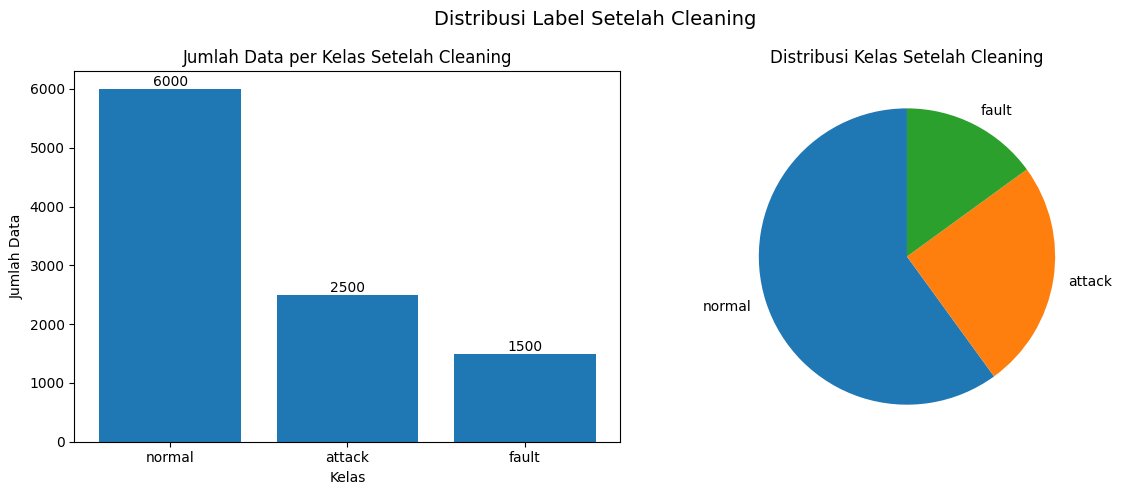

In [ ]:
# 1. DISTRIBUSI LABEL SETELAH CLEANING

label_counts = data_cleaned["label"].value_counts().sort_index()

label_summary = pd.DataFrame({
    "label": label_counts.index,
    "class_name": label_counts.index.map(label_mapping),
    "count": label_counts.values
})

display(label_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(
    label_summary["class_name"],
    label_summary["count"]
)

axes[0].set_title("Jumlah Data per Kelas Setelah Cleaning")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Data")

for index, value in enumerate(label_summary["count"]):
    axes[0].text(
        index,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

# Pie chart
axes[1].pie(
    label_summary["count"],
    labels=label_summary["class_name"],
    startangle=90
)

axes[1].set_title("Distribusi Kelas Setelah Cleaning")

plt.suptitle("Distribusi Label Setelah Cleaning", fontsize=14)
plt.tight_layout()
plt.show()

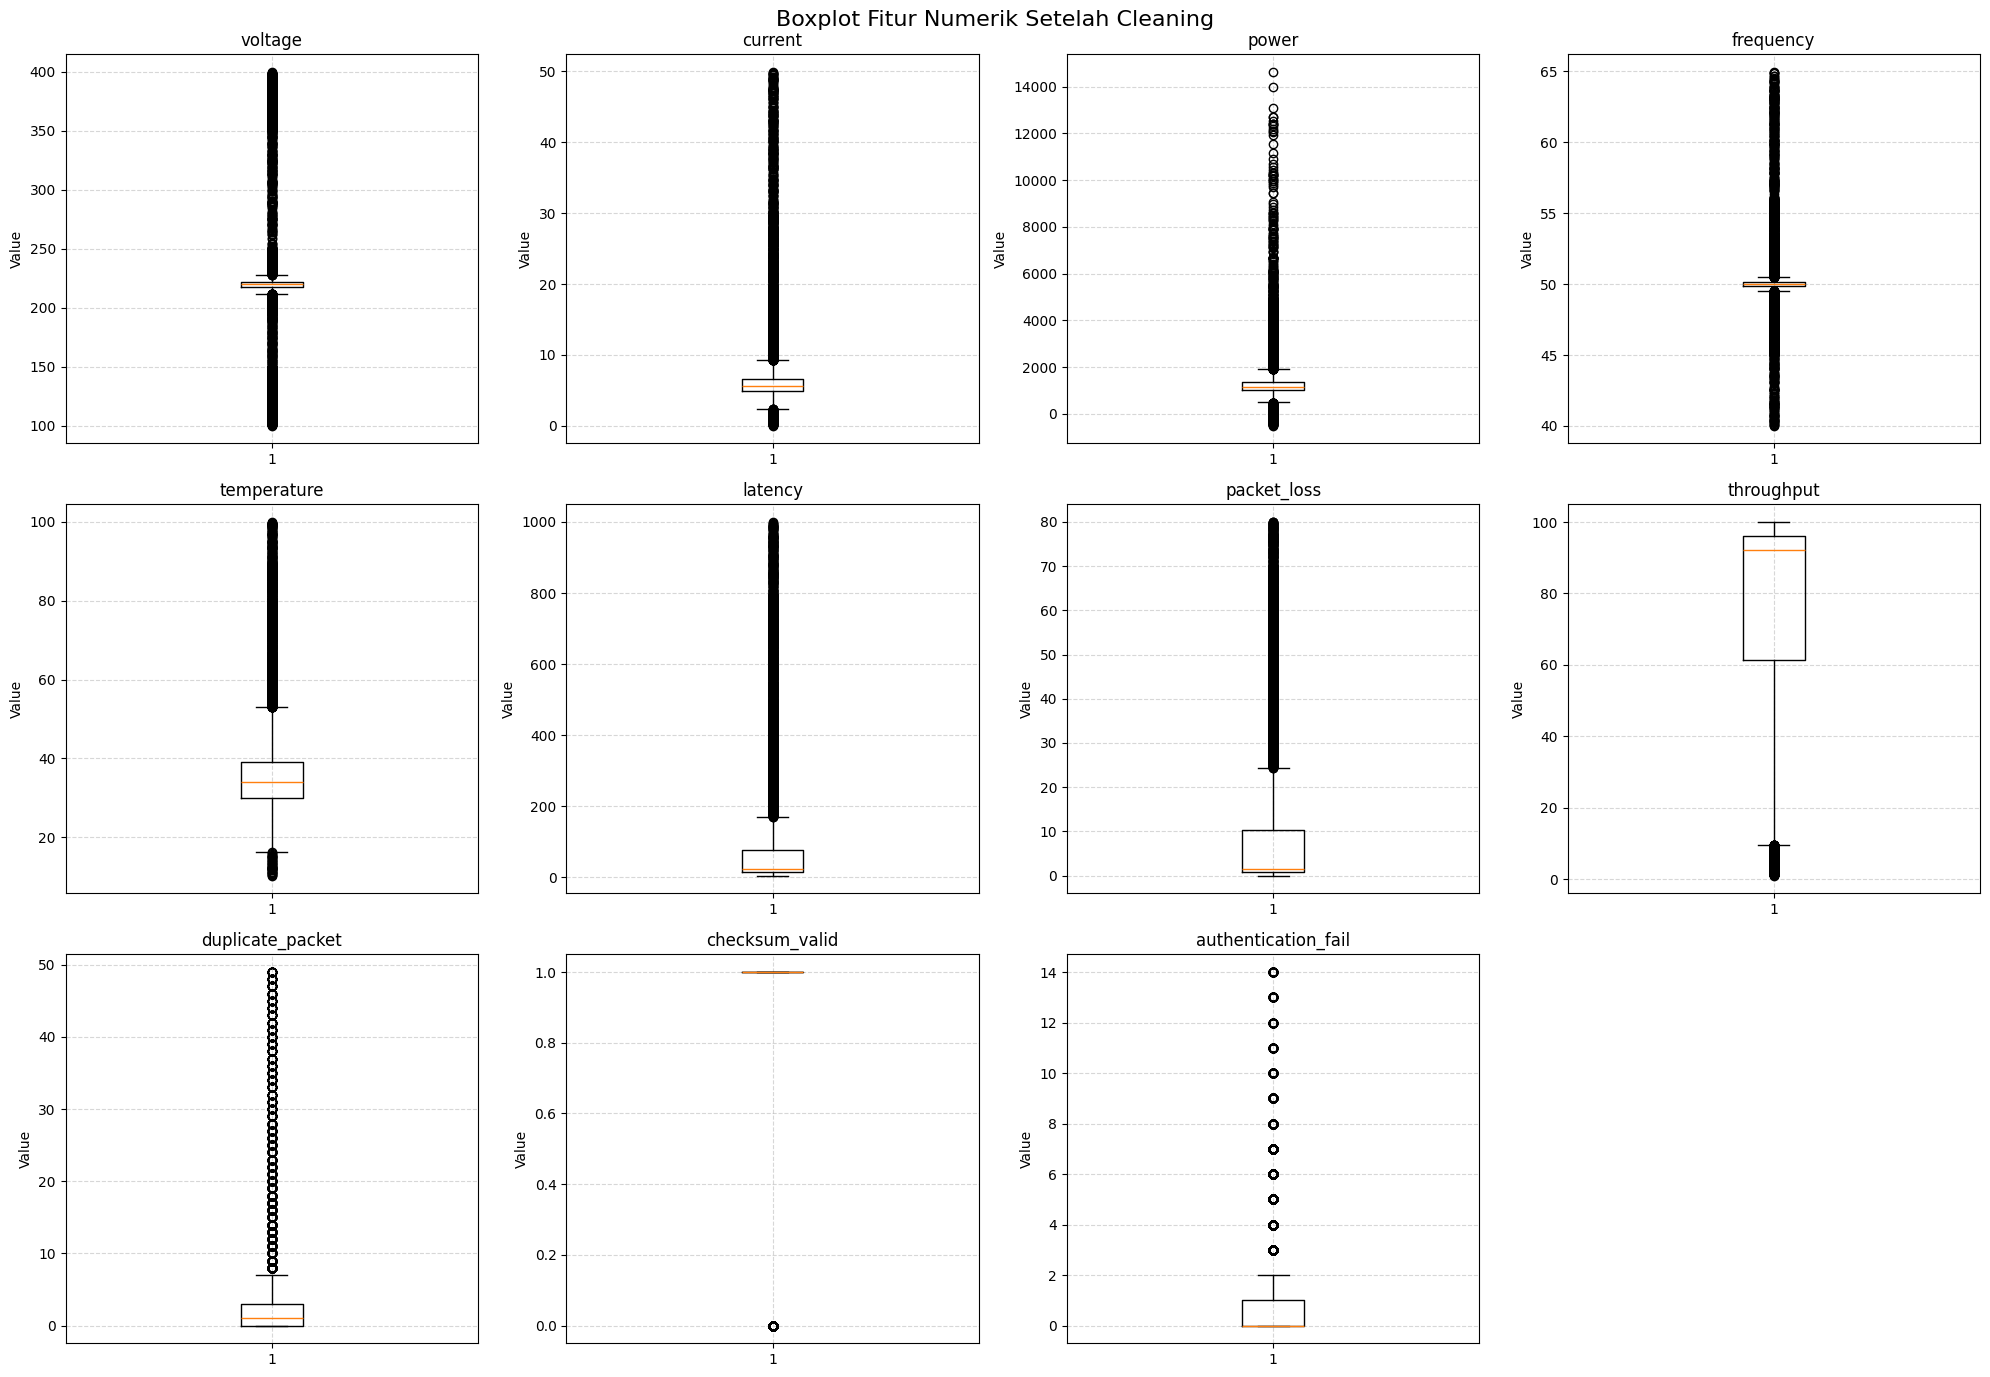

In [ ]:
# SETELAH CLEANING

num_features = len(numeric_feature_columns)

n_cols = 4
n_rows = math.ceil(num_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 14)
)

axes = axes.flatten()

for i, col in enumerate(numeric_feature_columns):
    axes[i].boxplot(
        data_cleaned[col],
        vert=True
    )

    axes[i].set_title(col)
    axes[i].set_ylabel("Value")
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Boxplot Fitur Numerik Setelah Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

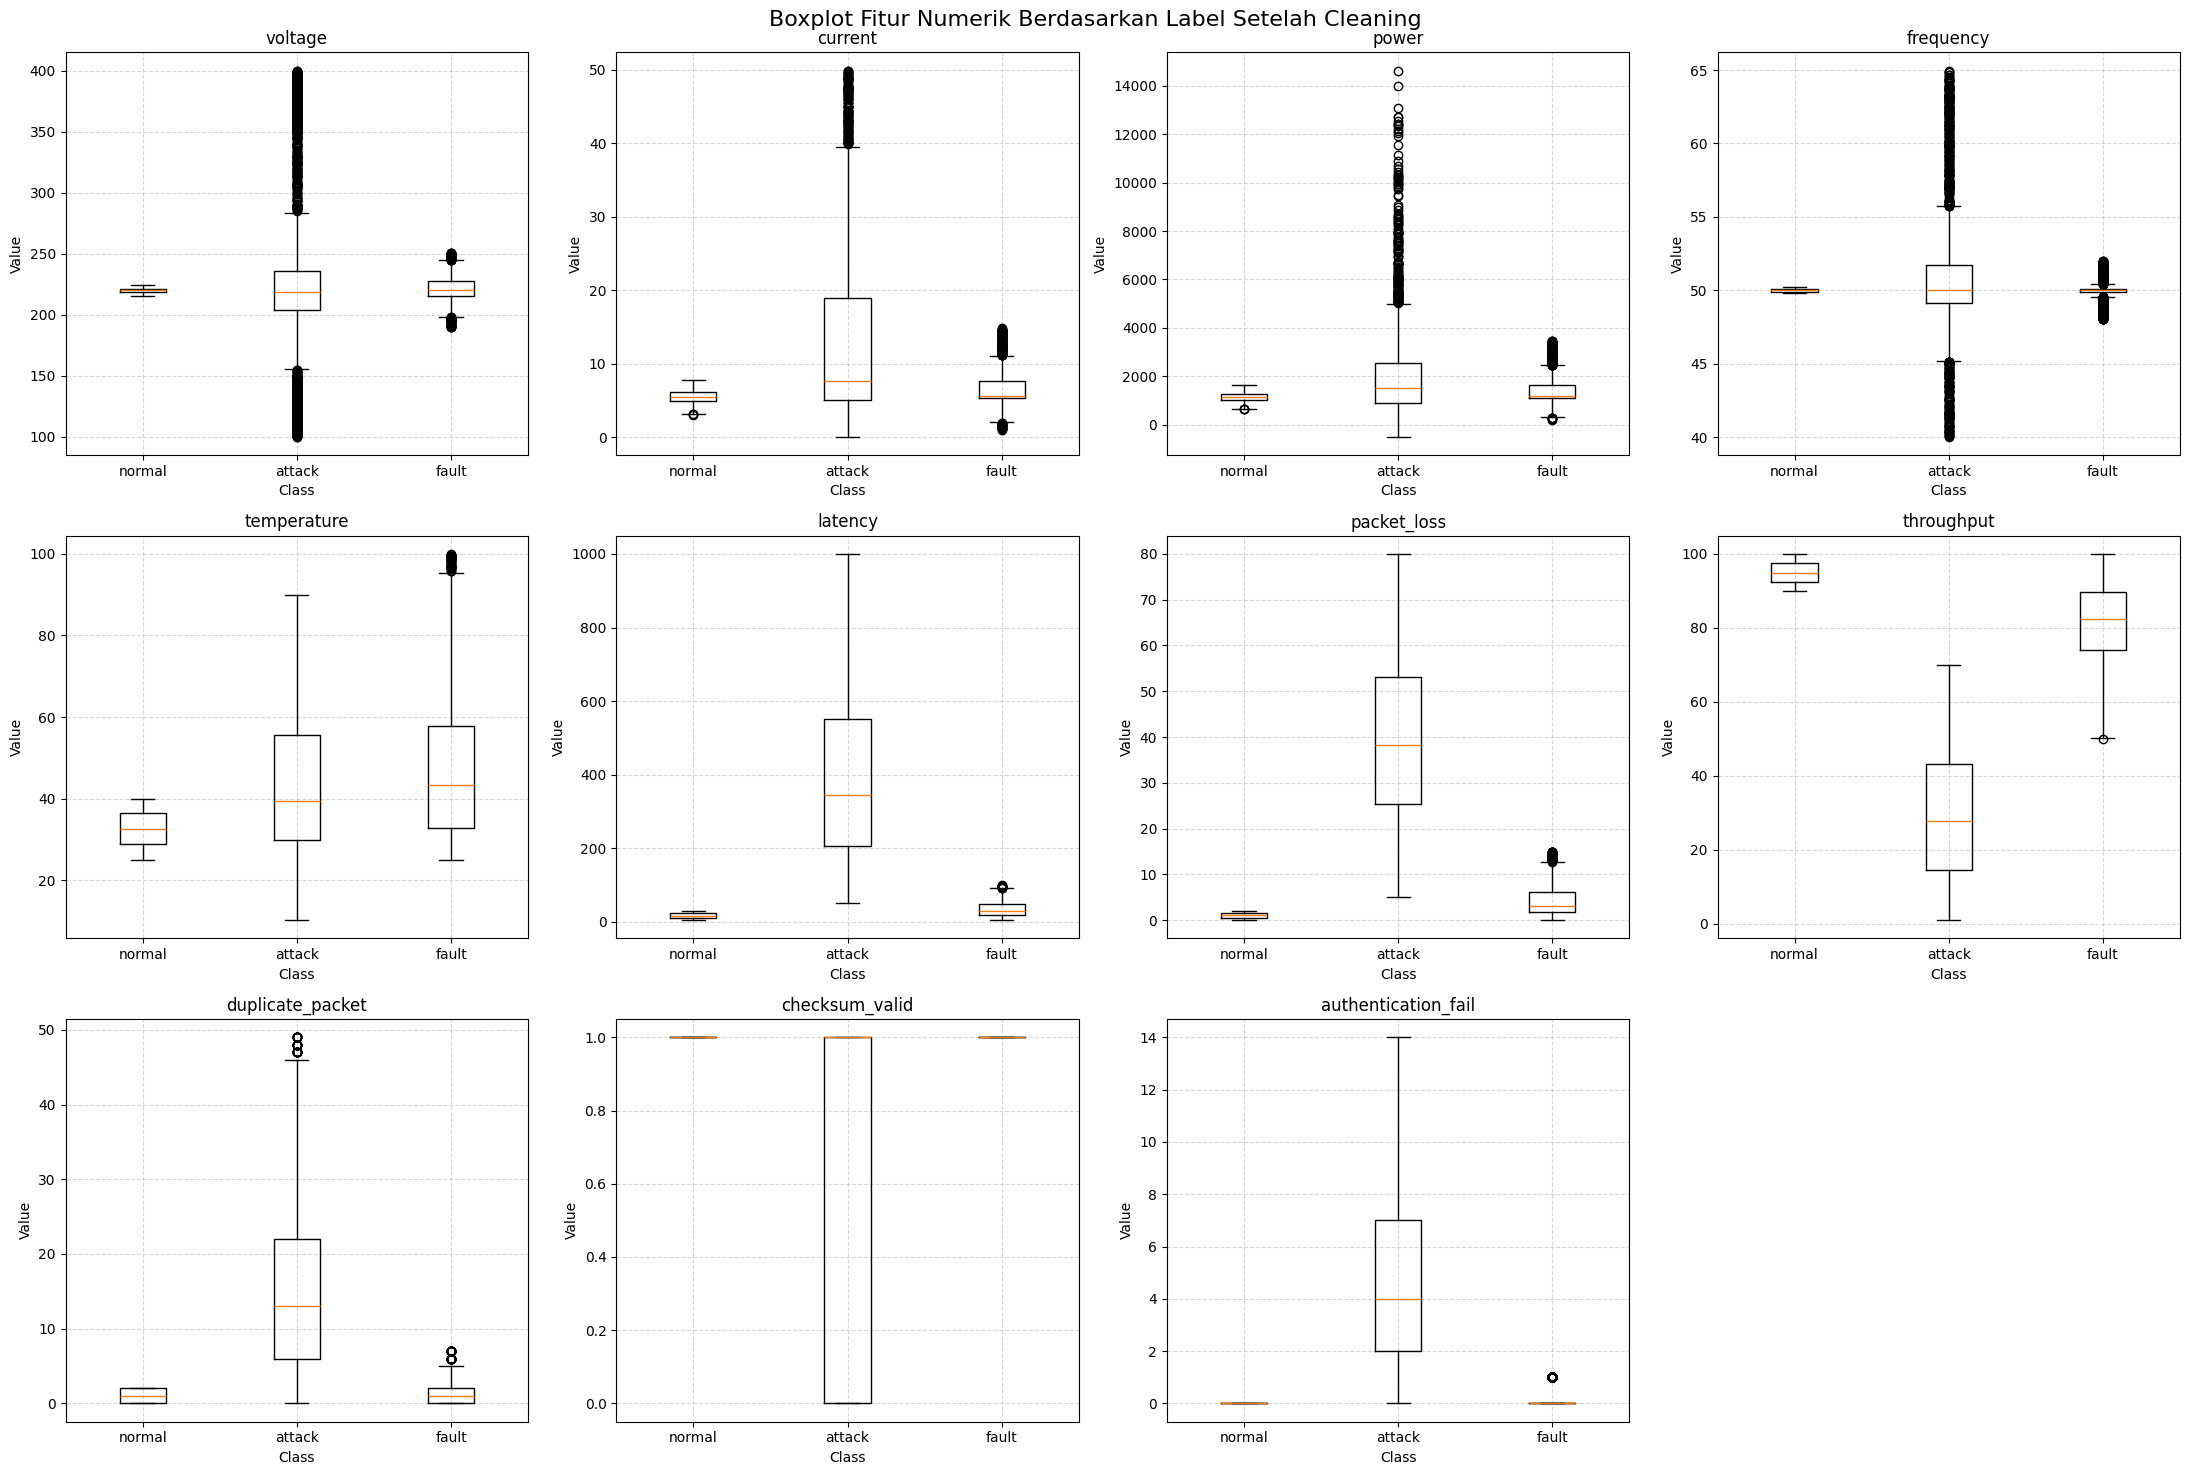

In [100]:
num_features = len(numeric_feature_columns)

n_cols = 4
n_rows = math.ceil(num_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 15)
)

axes = axes.flatten()

for i, col in enumerate(numeric_feature_columns):
    data_to_plot = [
        data_cleaned[data_cleaned["label"] == 0][col],
        data_cleaned[data_cleaned["label"] == 1][col],
        data_cleaned[data_cleaned["label"] == 2][col]
    ]

    axes[i].boxplot(
        data_to_plot,
        labels=["normal", "attack", "fault"]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Value")
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Boxplot Fitur Numerik Berdasarkan Label Setelah Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

,column,before_cleaning,after_cleaning
2,voltage,50,0
3,current,43,0
4,power,90,0
6,temperature,65,0


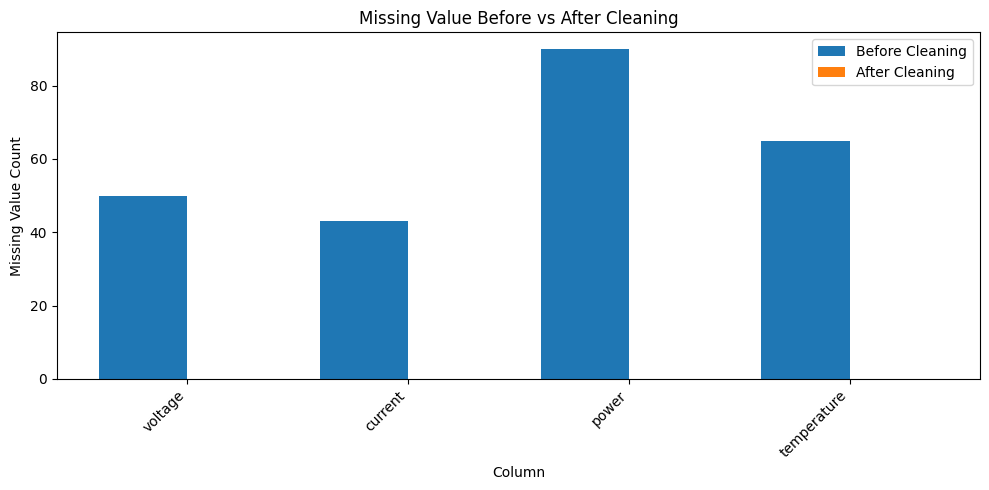

In [ ]:
# VISUALISASI MISSING VALUE BEFORE VS AFTER CLEANING

missing_before = data.isnull().sum()
missing_after = data_cleaned.isnull().sum()

missing_comparison = pd.DataFrame({
    "column": missing_before.index,
    "before_cleaning": missing_before.values,
    "after_cleaning": missing_after.values
})

# Ambil hanya kolom yang punya missing value sebelum/sesudah cleaning
missing_comparison = missing_comparison[
    (missing_comparison["before_cleaning"] > 0) |
    (missing_comparison["after_cleaning"] > 0)
]

display(missing_comparison)

plt.figure(figsize=(10, 5))

x = range(len(missing_comparison))

plt.bar(
    [i - 0.2 for i in x],
    missing_comparison["before_cleaning"],
    width=0.4,
    label="Before Cleaning"
)

plt.bar(
    [i + 0.2 for i in x],
    missing_comparison["after_cleaning"],
    width=0.4,
    label="After Cleaning"
)

plt.xticks(
    x,
    missing_comparison["column"],
    rotation=45,
    ha="right"
)

plt.title("Missing Value Before vs After Cleaning")
plt.xlabel("Column")
plt.ylabel("Missing Value Count")
plt.legend()
plt.tight_layout()
plt.show()

### Feature and Target Selection

In [102]:
data_model = data_cleaned.copy()

target_column = "label"

feature_columns = [
    "voltage",
    "current",
    "power",
    "frequency",
    "temperature",
    "latency",
    "packet_loss",
    "throughput",
    "duplicate_packet",
    "checksum_valid",
    "authentication_fail"
]

print("Feature and target selection dimulai.")
print("Target column:", target_column)
print("Feature columns:")
print(feature_columns)

Feature and target selection dimulai.
Target column: label
Feature columns:
['voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail']


In [103]:
required_columns = feature_columns + [target_column]

missing_columns = [
    col for col in required_columns
    if col not in data_model.columns
]

if len(missing_columns) == 0:
    print("Semua kolom fitur dan target tersedia.")
else:
    print("Ada kolom yang tidak ditemukan:")
    print(missing_columns)

Semua kolom fitur dan target tersedia.


In [104]:
X = data_model[feature_columns]
y = data_model[target_column]

print("Fitur X dan target y berhasil dibuat.")
print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nPreview X:")
display(X.head())

print("\nPreview y:")
display(y.head())

Fitur X dan target y berhasil dibuat.
Shape X: (10000, 11)
Shape y: (10000,)

Preview X:


,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail
0,362.7721,4.8409,543.9913,51.0723,68.2365,650.3120,64.0091,34.7634,2.0,0,5
1,219.9191,5.2442,1095.6327,50.0000,30.0000,208.4703,15.6947,36.2824,27.0,1,2
2,219.6843,6.5328,1363.3934,49.9166,27.3897,20.8755,0.3336,93.3756,1.0,1,0
3,217.1400,4.7727,984.5324,49.8375,39.9490,22.3209,1.4493,97.4572,0.0,1,0
4,219.5477,5.0714,1057.7341,50.1409,32.7594,28.3325,1.2772,91.4877,0.0,1,0



Preview y:


0    1
1    1
2    0
3    0
4    0
Name: label, dtype: int64

In [105]:
print("Tipe data fitur X:")
print(X.dtypes)

print("\nTipe data target y:")
print(y.dtypes)

Tipe data fitur X:
voltage                float64
current                float64
power                  float64
frequency              float64
temperature            float64
latency                float64
packet_loss            float64
throughput             float64
duplicate_packet       float64
checksum_valid           int64
authentication_fail      int64
dtype: object

Tipe data target y:
int64


In [ ]:
non_numeric_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

if len(non_numeric_features) == 0:
    print("Semua fitur sudah bertipe numerik.")
else:
    print("Ada fitur yang belum numerik:")
    print(non_numeric_features)

Semua fitur sudah bertipe numerik.


In [109]:
y = y.astype(int)

print("Target berhasil dipastikan bertipe integer.")
print("Tipe data target setelah konversi:", y.dtype)

Target berhasil dipastikan bertipe integer.
Tipe data target setelah konversi: int64


In [110]:
print("Missing value pada X:")
print(X.isnull().sum())

print("\nMissing value pada y:")
print(y.isnull().sum())

total_missing_x = X.isnull().sum().sum()
total_missing_y = y.isnull().sum()

print("\nTotal missing value pada X:", total_missing_x)
print("Total missing value pada y:", total_missing_y)

Missing value pada X:
voltage                0
current                0
power                  0
frequency              0
temperature            0
latency                0
packet_loss            0
throughput             0
duplicate_packet       0
checksum_valid         0
authentication_fail    0
dtype: int64

Missing value pada y:
0

Total missing value pada X: 0
Total missing value pada y: 0


In [113]:
FEATURE_COLUMNS_PATH = MODELS_DIR / "feature_columns.pkl"

joblib.dump(feature_columns, FEATURE_COLUMNS_PATH)

print("Feature columns berhasil disimpan ke:")
print(FEATURE_COLUMNS_PATH)

print("\nFeature columns yang disimpan:")
print(feature_columns)

Feature columns berhasil disimpan ke:
E:\project-kda-kelompok3\models\feature_columns.pkl

Feature columns yang disimpan:
['voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail']


In [114]:
# ============================================================
# 6.10 RINGKASAN FEATURE AND TARGET SELECTION
# ============================================================

print("Ringkasan Feature and Target Selection")
print("=====================================")
print("Jumlah data        :", X.shape[0])
print("Jumlah fitur       :", X.shape[1])
print("Target column      :", target_column)
print("Mapping target     : 0 = normal, 1 = attack, 2 = fault")

print("\nFitur yang digunakan:")
for feature in feature_columns:
    print("-", feature)

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

Ringkasan Feature and Target Selection
Jumlah data        : 10000
Jumlah fitur       : 11
Target column      : label
Mapping target     : 0 = normal, 1 = attack, 2 = fault

Fitur yang digunakan:
- voltage
- current
- power
- frequency
- temperature
- latency
- packet_loss
- throughput
- duplicate_packet
- checksum_valid
- authentication_fail

Shape X: (10000, 11)
Shape y: (10000,)


## Train-Test Split

In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split berhasil dilakukan.")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Train-test split berhasil dilakukan.
X_train shape: (8000, 11)
X_test shape : (2000, 11)
y_train shape: (8000,)
y_test shape : (2000,)


In [116]:
train_percentage = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename(index=label_mapping)
)

test_percentage = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename(index=label_mapping)
)

print("Persentase kelas pada y_train:")
print(train_percentage)

print("\nPersentase kelas pada y_test:")
print(test_percentage)

Persentase kelas pada y_train:
label
normal    60.0
attack    25.0
fault     15.0
Name: proportion, dtype: float64

Persentase kelas pada y_test:
label
normal    60.0
attack    25.0
fault     15.0
Name: proportion, dtype: float64


In [117]:
split_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "total_data": [len(y_train), len(y_test)],
    "normal": [
        (y_train == 0).sum(),
        (y_test == 0).sum()
    ],
    "attack": [
        (y_train == 1).sum(),
        (y_test == 1).sum()
    ],
    "fault": [
        (y_train == 2).sum(),
        (y_test == 2).sum()
    ]
})

split_summary["normal_percentage"] = (
    split_summary["normal"] / split_summary["total_data"] * 100
).round(2)

split_summary["attack_percentage"] = (
    split_summary["attack"] / split_summary["total_data"] * 100
).round(2)

split_summary["fault_percentage"] = (
    split_summary["fault"] / split_summary["total_data"] * 100
).round(2)

display(split_summary)

,dataset,total_data,normal,attack,fault,normal_percentage,attack_percentage,fault_percentage
0,train,8000,4800,2000,1200,60.0,25.0,15.0
1,test,2000,1200,500,300,60.0,25.0,15.0


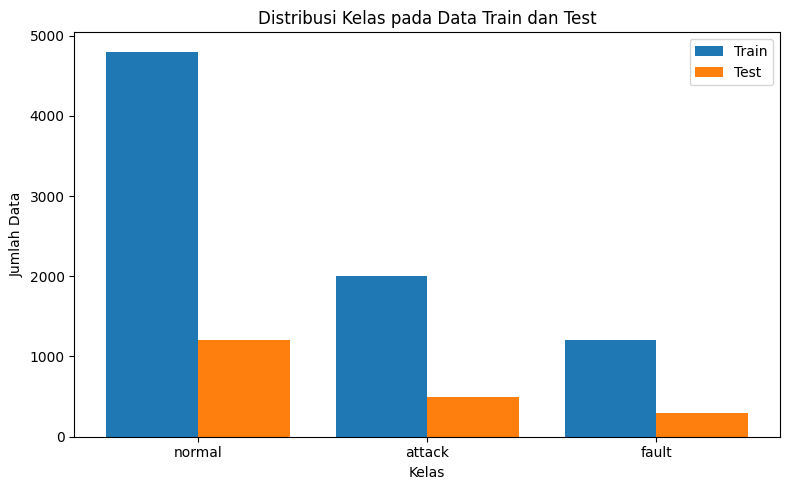

In [118]:
class_names = ["normal", "attack", "fault"]

train_counts = [
    (y_train == 0).sum(),
    (y_train == 1).sum(),
    (y_train == 2).sum()
]

test_counts = [
    (y_test == 0).sum(),
    (y_test == 1).sum(),
    (y_test == 2).sum()
]

x_axis = range(len(class_names))

plt.figure(figsize=(8, 5))

plt.bar(
    [x - 0.2 for x in x_axis],
    train_counts,
    width=0.4,
    label="Train"
)

plt.bar(
    [x + 0.2 for x in x_axis],
    test_counts,
    width=0.4,
    label="Test"
)

plt.xticks(x_axis, class_names)
plt.title("Distribusi Kelas pada Data Train dan Test")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.legend()
plt.tight_layout()
plt.show()

In [119]:
TRAIN_DATA_PATH = PROCESSED_DIR / "train_data.csv"
TEST_DATA_PATH = PROCESSED_DIR / "test_data.csv"

train_data = X_train.copy()
train_data[target_column] = y_train.values

test_data = X_test.copy()
test_data[target_column] = y_test.values

train_data.to_csv(TRAIN_DATA_PATH, index=False)
test_data.to_csv(TEST_DATA_PATH, index=False)

print("Data training berhasil disimpan ke:")
print(TRAIN_DATA_PATH)

print("\nData testing berhasil disimpan ke:")
print(TEST_DATA_PATH)

Data training berhasil disimpan ke:
E:\project-kda-kelompok3\data\processed\train_data.csv

Data testing berhasil disimpan ke:
E:\project-kda-kelompok3\data\processed\test_data.csv


## Scalling

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil dilakukan.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

Scaling berhasil dilakukan.
X_train_scaled shape: (8000, 11)
X_test_scaled shape : (2000, 11)


In [121]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_columns,
    index=X_test.index
)

print("Data scaling berhasil diubah menjadi DataFrame.")

print("\nPreview X_train_scaled_df:")
display(X_train_scaled_df.head())

print("\nPreview X_test_scaled_df:")
display(X_test_scaled_df.head())

Data scaling berhasil diubah menjadi DataFrame.

Preview X_train_scaled_df:


,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail
623,-0.187280,-0.319636,-0.297200,-0.097993,-0.387593,-0.409182,-0.473107,0.609406,-0.426191,0.319500,-0.451667
4002,-0.115638,-0.381654,-0.361452,-0.151929,-0.170413,-0.429188,-0.578857,0.489501,-0.426191,0.319500,-0.451667
3837,3.870627,-0.977910,2.197489,0.087601,-0.654250,2.957755,1.779554,-1.212382,1.435412,-3.129892,1.476681
1312,-0.155138,-0.429591,-0.427513,-0.016188,0.116843,-0.469915,-0.585671,0.676226,-0.426191,0.319500,-0.451667
9150,4.267041,-0.487220,-0.389011,5.392973,1.239069,3.365838,2.049645,-1.777799,1.551762,0.319500,2.633690



Preview X_test_scaled_df:


,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail
9885,-0.137169,-0.266656,-0.222193,-0.135312,-0.058831,-0.483502,-0.498261,0.755940,-0.542541,0.319500,-0.451667
9216,3.820986,2.186433,1.253659,3.732118,-1.169089,1.354416,2.325840,-1.271647,1.202711,-3.129892,1.091011
4088,-0.076211,-0.342253,-0.305278,-0.125721,-0.217666,-0.450012,-0.520443,0.795835,-0.309840,0.319500,-0.451667
5390,-1.102674,0.939740,1.707092,-0.470654,0.091738,-0.118129,-0.038344,-0.708413,0.388260,0.319500,0.705342
3644,-0.139824,-0.282939,-0.242947,-0.082563,-0.166496,-0.475118,-0.498082,0.540863,-0.309840,0.319500,-0.451667


In [122]:
# ============================================================
# 8.2 CEK STATISTIK SETELAH SCALING
# ============================================================

print("Rata-rata fitur setelah scaling pada data training:")
display(X_train_scaled_df.mean().round(4))

print("\nStandar deviasi fitur setelah scaling pada data training:")
display(X_train_scaled_df.std().round(4))

Rata-rata fitur setelah scaling pada data training:


voltage                0.0
current                0.0
power                 -0.0
frequency              0.0
temperature           -0.0
latency               -0.0
packet_loss           -0.0
throughput            -0.0
duplicate_packet      -0.0
checksum_valid        -0.0
authentication_fail   -0.0
dtype: float64


Standar deviasi fitur setelah scaling pada data training:


voltage                1.0001
current                1.0001
power                  1.0001
frequency              1.0001
temperature            1.0001
latency                1.0001
packet_loss            1.0001
throughput             1.0001
duplicate_packet       1.0001
checksum_valid         1.0001
authentication_fail    1.0001
dtype: float64

In [ ]:
scaling_comparison = pd.DataFrame({
    "feature": feature_columns,
    "mean_before": X_train[feature_columns].mean().values,
    "std_before": X_train[feature_columns].std().values,
    "mean_after": X_train_scaled_df[feature_columns].mean().values,
    "std_after": X_train_scaled_df[feature_columns].std().values
})

display(scaling_comparison)

,feature,mean_before,std_before,mean_after,std_after
0,voltage,223.007978,39.437477,3.579359e-16,1.000063
1,current,7.456548,6.583989,1.598721e-17,1.000063
2,power,1421.865867,1095.319898,-2.620126e-17,1.000063
3,frequency,50.206394,2.106336,9.512391e-16,1.000063
4,temperature,38.142574,13.938620,-7.993606e-17,1.000063
5,latency,113.781776,199.481900,-3.286260e-17,1.000063
6,packet_loss,11.169288,19.020732,-1.088019e-16,1.000063
7,throughput,76.556271,29.396925,-3.552714e-18,1.000063
8,duplicate_packet,4.663000,8.595285,-3.419487e-17,1.000063
9,checksum_valid,0.907375,0.289924,-1.225686e-16,1.000063


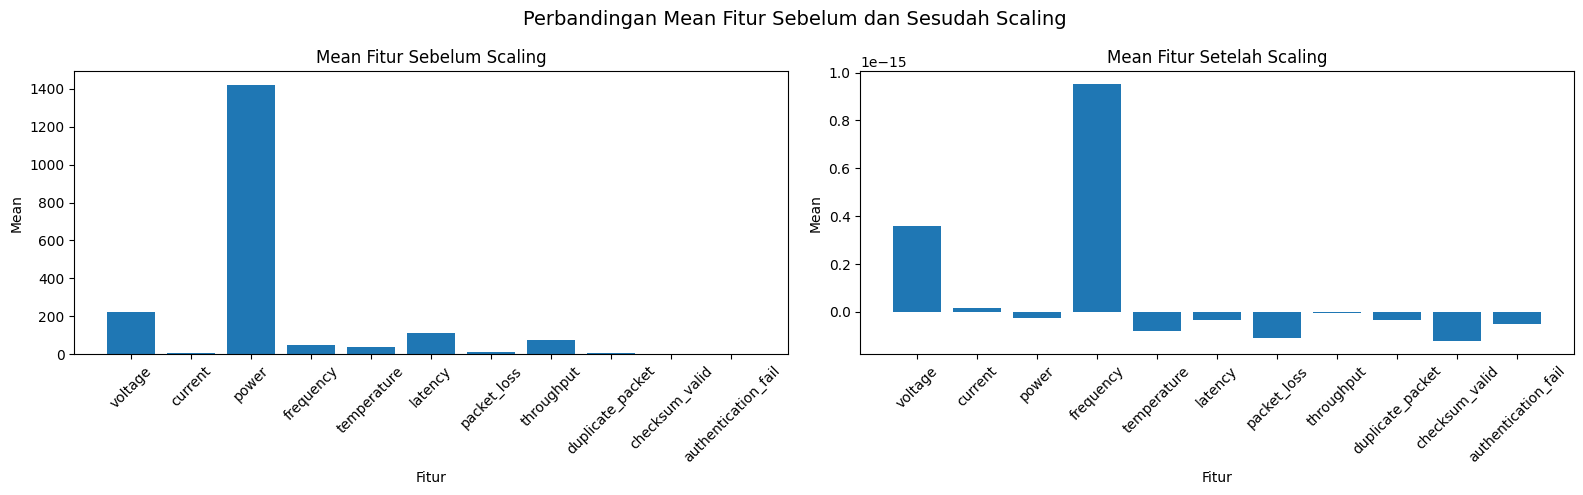

In [124]:
import matplotlib.pyplot as plt

# Ambil nilai mean absolute supaya mudah dibandingkan
mean_before = X_train[feature_columns].mean()
mean_after = X_train_scaled_df[feature_columns].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sebelum scaling
axes[0].bar(feature_columns, mean_before)
axes[0].set_title("Mean Fitur Sebelum Scaling")
axes[0].set_xlabel("Fitur")
axes[0].set_ylabel("Mean")
axes[0].tick_params(axis="x", rotation=45)

# Sesudah scaling
axes[1].bar(feature_columns, mean_after)
axes[1].set_title("Mean Fitur Setelah Scaling")
axes[1].set_xlabel("Fitur")
axes[1].set_ylabel("Mean")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Perbandingan Mean Fitur Sebelum dan Sesudah Scaling", fontsize=14)
plt.tight_layout()
plt.show()

In [125]:
# ============================================================
# 8.5 SIMPAN SCALER
# ============================================================

SCALER_PATH = MODELS_DIR / "scaler.pkl"

joblib.dump(scaler, SCALER_PATH)

print("Scaler berhasil disimpan ke:")
print(SCALER_PATH)

Scaler berhasil disimpan ke:
E:\project-kda-kelompok3\models\scaler.pkl


In [126]:
# ============================================================
# 8.6 SIMPAN DATA HASIL SCALING
# ============================================================

TRAIN_SCALED_PATH = PROCESSED_DIR / "train_scaled.csv"
TEST_SCALED_PATH = PROCESSED_DIR / "test_scaled.csv"

train_scaled_data = X_train_scaled_df.copy()
train_scaled_data[target_column] = y_train.values

test_scaled_data = X_test_scaled_df.copy()
test_scaled_data[target_column] = y_test.values

train_scaled_data.to_csv(TRAIN_SCALED_PATH, index=False)
test_scaled_data.to_csv(TEST_SCALED_PATH, index=False)

print("Data training hasil scaling berhasil disimpan ke:")
print(TRAIN_SCALED_PATH)

print("\nData testing hasil scaling berhasil disimpan ke:")
print(TEST_SCALED_PATH)

Data training hasil scaling berhasil disimpan ke:
E:\project-kda-kelompok3\data\processed\train_scaled.csv

Data testing hasil scaling berhasil disimpan ke:
E:\project-kda-kelompok3\data\processed\test_scaled.csv


In [127]:
# ============================================================
# 8.7 RINGKASAN SCALING
# ============================================================

print("Ringkasan Scaling")
print("=================")
print("Metode scaling        : StandardScaler")
print("Fit dilakukan pada    : X_train")
print("Transform dilakukan   : X_train dan X_test")
print("Alasan scaling        : Menyamakan skala fitur agar Logistic Regression lebih stabil")
print("Jumlah fitur          :", len(feature_columns))
print("Fitur yang di-scaling :")

for feature in feature_columns:
    print("-", feature)

print("\nOutput utama:")
print("X_train_scaled_df:", X_train_scaled_df.shape)
print("X_test_scaled_df :", X_test_scaled_df.shape)

print("\nScaler disimpan di:")
print(SCALER_PATH)

Ringkasan Scaling
Metode scaling        : StandardScaler
Fit dilakukan pada    : X_train
Transform dilakukan   : X_train dan X_test
Alasan scaling        : Menyamakan skala fitur agar Logistic Regression lebih stabil
Jumlah fitur          : 11
Fitur yang di-scaling :
- voltage
- current
- power
- frequency
- temperature
- latency
- packet_loss
- throughput
- duplicate_packet
- checksum_valid
- authentication_fail

Output utama:
X_train_scaled_df: (8000, 11)
X_test_scaled_df : (2000, 11)

Scaler disimpan di:
E:\project-kda-kelompok3\models\scaler.pkl


## Modelling

### Train Individual Models

In [128]:
# ============================================================
# 9. TRAIN INDIVIDUAL MODELS
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Logistic Regression
# Cocok untuk multiclass classification dengan solver lbfgs
logistic_regression_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)

print("Model individual berhasil dibuat:")
print("1. Decision Tree")
print("2. Random Forest")
print("3. Logistic Regression")

Model individual berhasil dibuat:
1. Decision Tree
2. Random Forest
3. Logistic Regression


In [129]:
decision_tree_model.fit(X_train_scaled_df, y_train)

print("Decision Tree berhasil dilatih.")

Decision Tree berhasil dilatih.


In [130]:
random_forest_model.fit(X_train_scaled_df, y_train)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


In [131]:
logistic_regression_model.fit(X_train_scaled_df, y_train)

print("Logistic Regression berhasil dilatih.")

Logistic Regression berhasil dilatih.


In [132]:
dt_pred = decision_tree_model.predict(X_test_scaled_df)
rf_pred = random_forest_model.predict(X_test_scaled_df)
lr_pred = logistic_regression_model.predict(X_test_scaled_df)

print("Prediksi model individual berhasil dilakukan.")
print("Jumlah prediksi Decision Tree      :", len(dt_pred))
print("Jumlah prediksi Random Forest      :", len(rf_pred))
print("Jumlah prediksi Logistic Regression:", len(lr_pred))

Prediksi model individual berhasil dilakukan.
Jumlah prediksi Decision Tree      : 2000
Jumlah prediksi Random Forest      : 2000
Jumlah prediksi Logistic Regression: 2000


In [134]:
label_mapping = {
    0: "normal",
    1: "attack",
    2: "fault"
}

preview_prediction = pd.DataFrame({
    "actual_label": y_test.values,
    "decision_tree_prediction": dt_pred,
    "random_forest_prediction": rf_pred,
    "logistic_regression_prediction": lr_pred
})

preview_prediction["actual_class"] = preview_prediction["actual_label"].map(label_mapping)
preview_prediction["decision_tree_class"] = preview_prediction["decision_tree_prediction"].map(label_mapping)
preview_prediction["random_forest_class"] = preview_prediction["random_forest_prediction"].map(label_mapping)
preview_prediction["logistic_regression_class"] = preview_prediction["logistic_regression_prediction"].map(label_mapping)

display(preview_prediction.head(200))

,actual_label,decision_tree_prediction,random_forest_prediction,logistic_regression_prediction,actual_class,decision_tree_class,random_forest_class,logistic_regression_class
0,0,0,0,0,normal,normal,normal,normal
1,1,1,1,1,attack,attack,attack,attack
2,0,0,0,0,normal,normal,normal,normal
3,1,1,1,1,attack,attack,attack,attack
4,0,0,0,0,normal,normal,normal,normal
...,...,...,...,...,...,...,...,...
195,1,1,1,1,attack,attack,attack,attack
196,0,0,0,0,normal,normal,normal,normal
197,0,0,0,0,normal,normal,normal,normal
198,2,2,2,2,fault,fault,fault,fault


## Evaluate Individual Models


In [135]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

label_mapping = {
    0: "normal",
    1: "attack",
    2: "fault"
}

target_names = ["normal", "attack", "fault"]

print("Evaluasi model individual dimulai.")

Evaluasi model individual dimulai.


In [136]:
def evaluate_individual_model(model_name, y_true, y_pred):
    """
    Function untuk mengevaluasi model multiclass classification.
    Kelas:
    0 = normal
    1 = attack
    2 = fault
    """

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2]
    )

    print("=" * 70)
    print(f"Evaluation Result: {model_name}")
    print("=" * 70)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            target_names=target_names,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(cm)

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

In [137]:
dt_evaluation = evaluate_individual_model(
    model_name="Decision Tree",
    y_true=y_test,
    y_pred=dt_pred
)

Evaluation Result: Decision Tree
Accuracy : 0.9965
Precision: 0.9964936396382781
Recall   : 0.9965
F1-score : 0.9964921423597388

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      1200
      attack       1.00      1.00      1.00       500
       fault       0.99      0.98      0.99       300

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
[[1200    0    0]
 [   0  498    2]
 [   3    2  295]]


In [138]:
rf_evaluation = evaluate_individual_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=rf_pred
)

Evaluation Result: Random Forest
Accuracy : 0.998
Precision: 0.9979991401355682
Recall   : 0.998
F1-score : 0.9979974881578616

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      1200
      attack       1.00      1.00      1.00       500
       fault       1.00      0.99      0.99       300

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
[[1199    0    1]
 [   0  500    0]
 [   3    0  297]]


In [139]:
lr_evaluation = evaluate_individual_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=lr_pred
)

Evaluation Result: Logistic Regression
Accuracy : 0.968
Precision: 0.9694410068065231
Recall   : 0.968
F1-score : 0.966558745941718

Classification Report:
              precision    recall  f1-score   support

      normal       0.95      1.00      0.97      1200
      attack       1.00      1.00      1.00       500
       fault       1.00      0.79      0.88       300

    accuracy                           0.97      2000
   macro avg       0.98      0.93      0.95      2000
weighted avg       0.97      0.97      0.97      2000

Confusion Matrix:
[[1200    0    0]
 [   0  499    1]
 [  63    0  237]]


In [140]:
# ============================================================
# 10.5 TABEL PERBANDINGAN EVALUASI MODEL INDIVIDUAL
# ============================================================

evaluation_results = pd.DataFrame([
    {
        "model": dt_evaluation["model"],
        "accuracy": dt_evaluation["accuracy"],
        "precision": dt_evaluation["precision"],
        "recall": dt_evaluation["recall"],
        "f1_score": dt_evaluation["f1_score"]
    },
    {
        "model": rf_evaluation["model"],
        "accuracy": rf_evaluation["accuracy"],
        "precision": rf_evaluation["precision"],
        "recall": rf_evaluation["recall"],
        "f1_score": rf_evaluation["f1_score"]
    },
    {
        "model": lr_evaluation["model"],
        "accuracy": lr_evaluation["accuracy"],
        "precision": lr_evaluation["precision"],
        "recall": lr_evaluation["recall"],
        "f1_score": lr_evaluation["f1_score"]
    }
])

display(evaluation_results)

,model,accuracy,precision,recall,f1_score
0,Decision Tree,0.9965,0.996494,0.9965,0.996492
1,Random Forest,0.9980,0.997999,0.9980,0.997997
2,Logistic Regression,0.9680,0.969441,0.9680,0.966559


In [142]:
# ============================================================
# 10.7 FUNCTION VISUALISASI CONFUSION MATRIX
# ============================================================

def plot_confusion_matrix(cm, model_name):
    """
    Function untuk menampilkan confusion matrix multiclass.
    """

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()

    tick_marks = np.arange(len(target_names))

    plt.xticks(tick_marks, target_names)
    plt.yticks(tick_marks, target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

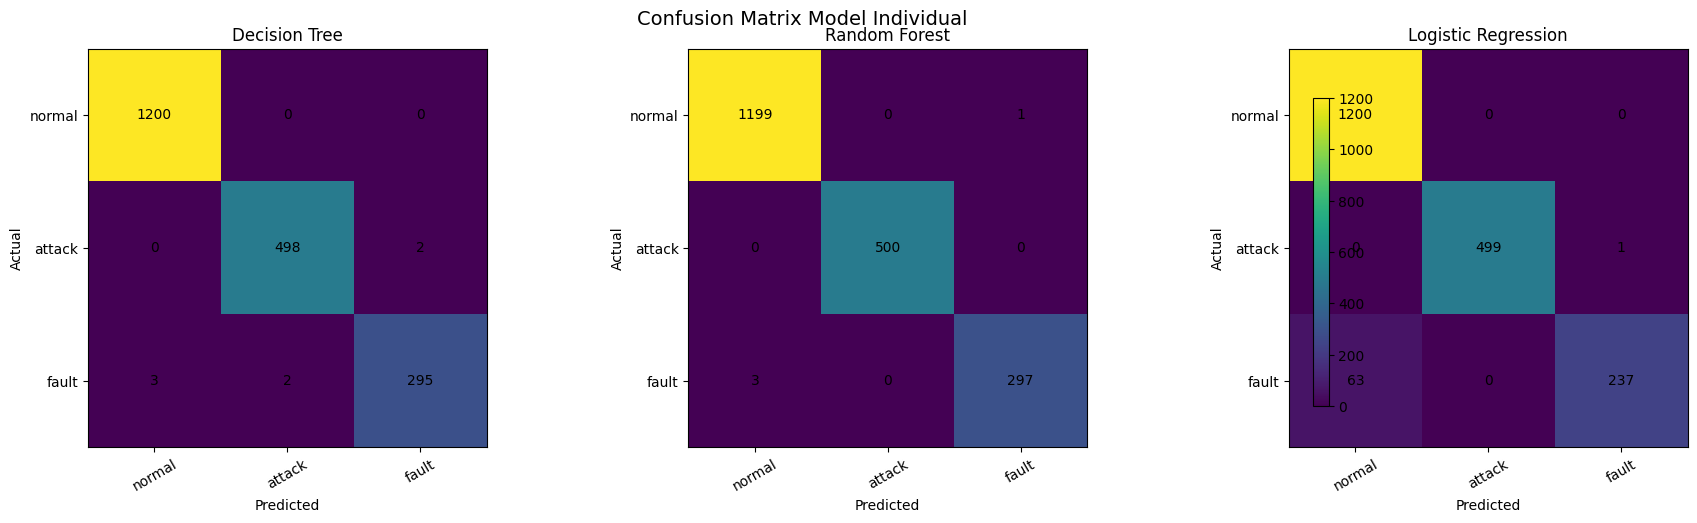

In [ ]:
confusion_matrices = [
    ("Decision Tree", dt_evaluation["confusion_matrix"]),
    ("Random Forest", rf_evaluation["confusion_matrix"]),
    ("Logistic Regression", lr_evaluation["confusion_matrix"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, cm) in zip(axes, confusion_matrices):
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(model_name)

    tick_marks = np.arange(len(target_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(target_names, rotation=30)
    ax.set_yticklabels(target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.suptitle("Confusion Matrix Model Individual", fontsize=14)
plt.tight_layout()
plt.show()

## ENSEMBLE MODELS

Decision Tree
Random Forest
Logistic Regression

In [ ]:
from sklearn.ensemble import VotingClassifier

# Hard voting berarti hasil akhir ditentukan dari suara mayoritas model
ensemble_model = VotingClassifier(
    estimators=[
        ("decision_tree", decision_tree_model),
        ("random_forest", random_forest_model),
        ("logistic_regression", logistic_regression_model)
    ],
    voting="hard"
)

print("Ensemble model berhasil dibuat.")
print("Model yang digabungkan:")
print("1. Decision Tree")
print("2. Random Forest")
print("3. Logistic Regression")
print("\nMetode ensemble: Hard Voting")

In [ ]:
# ============================================================
# 12.1 TRAINING ENSEMBLE MODEL
# ============================================================

ensemble_model.fit(X_train_scaled_df, y_train)

print("Ensemble model berhasil dilatih menggunakan data training.")
print("Shape X_train_scaled_df:", X_train_scaled_df.shape)
print("Shape y_train          :", y_train.shape)

In [ ]:
# ============================================================
# 12.2 PREDIKSI MENGGUNAKAN ENSEMBLE MODEL
# ============================================================

ensemble_pred = ensemble_model.predict(X_test_scaled_df)

print("Prediksi menggunakan ensemble model berhasil dilakukan.")
print("Jumlah hasil prediksi:", len(ensemble_pred))
print("Contoh hasil prediksi:", ensemble_pred[:10])

In [ ]:
# ============================================================
# 12.3 EVALUASI ENSEMBLE MODEL
# ============================================================

ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
ensemble_precision = precision_score(y_test, ensemble_pred, zero_division=0)
ensemble_recall = recall_score(y_test, ensemble_pred, zero_division=0)
ensemble_f1 = f1_score(y_test, ensemble_pred, zero_division=0)

print("Evaluasi Ensemble Model")
print("=======================")
print("Accuracy :", ensemble_accuracy)
print("Precision:", ensemble_precision)
print("Recall   :", ensemble_recall)
print("F1-score :", ensemble_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    ensemble_pred,
    target_names=["normal", "attack"],
    zero_division=0
))

print("Confusion Matrix:")
ensemble_cm = confusion_matrix(y_test, ensemble_pred)
print(ensemble_cm)

In [ ]:
# ============================================================
# 12.4 VISUALISASI CONFUSION MATRIX ENSEMBLE
# ============================================================

plt.figure(figsize=(5, 4))
plt.imshow(ensemble_cm, interpolation="nearest")
plt.title("Confusion Matrix - Ensemble Voting Classifier")
plt.colorbar()

class_names = ["normal", "attack"]
tick_marks = range(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

for i in range(ensemble_cm.shape[0]):
    for j in range(ensemble_cm.shape[1]):
        plt.text(
            j,
            i,
            ensemble_cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 12.5 BANDINGKAN ENSEMBLE DENGAN MODEL INDIVIDUAL
# ============================================================

ensemble_result = pd.DataFrame({
    "model": ["Voting Classifier Ensemble"],
    "accuracy": [ensemble_accuracy],
    "precision": [ensemble_precision],
    "recall": [ensemble_recall],
    "f1_score": [ensemble_f1]
})

comparison_results = pd.concat(
    [evaluation_results, ensemble_result],
    ignore_index=True
)

display(comparison_results)

In [ ]:
# ============================================================
# 12.6 VISUALISASI PERBANDINGAN MODEL INDIVIDUAL DAN ENSEMBLE
# ============================================================

metrics = ["accuracy", "precision", "recall", "f1_score"]

for metric in metrics:
    plt.figure(figsize=(8, 4))
    plt.bar(comparison_results["model"], comparison_results[metric])
    plt.title(f"Perbandingan {metric.capitalize()} Model")
    plt.xlabel("Model")
    plt.ylabel(metric.capitalize())
    plt.ylim(0, 1.05)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 12.7 SIMPAN ENSEMBLE MODEL
# ============================================================

ENSEMBLE_MODEL_PATH = MODELS_DIR / "ensemble_model.pkl"

joblib.dump(ensemble_model, ENSEMBLE_MODEL_PATH)

print("Ensemble model berhasil disimpan ke:")
print(ENSEMBLE_MODEL_PATH)

In [ ]:
# ============================================================
# 12.8 SIMPAN HASIL EVALUASI ENSEMBLE
# ============================================================

ENSEMBLE_EVALUATION_PATH = OUTPUTS_DIR / "ensemble_model_evaluation.csv"

ensemble_result.to_csv(ENSEMBLE_EVALUATION_PATH, index=False)

print("Hasil evaluasi ensemble model berhasil disimpan ke:")
print(ENSEMBLE_EVALUATION_PATH)

In [ ]:
# ============================================================
# 12.9 SIMPAN PERBANDINGAN SEMUA MODEL
# ============================================================

MODEL_COMPARISON_PATH = OUTPUTS_DIR / "model_comparison_results.csv"

comparison_results.to_csv(MODEL_COMPARISON_PATH, index=False)

print("Hasil perbandingan semua model berhasil disimpan ke:")
print(MODEL_COMPARISON_PATH)

In [ ]:
# ============================================================
# 12.10 SIMPAN CLASSIFICATION REPORT ENSEMBLE KE TXT
# ============================================================

ENSEMBLE_REPORT_PATH = OUTPUTS_DIR / "ensemble_classification_report.txt"

with open(ENSEMBLE_REPORT_PATH, "w") as file:
    file.write("ENSEMBLE MODEL CLASSIFICATION REPORT\n")
    file.write("=" * 60)
    file.write("\n\n")
    
    file.write("Voting Classifier Ensemble\n")
    file.write("-" * 60)
    file.write("\n")
    file.write(classification_report(
        y_test,
        ensemble_pred,
        target_names=["normal", "attack"],
        zero_division=0
    ))
    
    file.write("\n\nConfusion Matrix\n")
    file.write("-" * 60)
    file.write("\n")
    file.write(str(ensemble_cm))
    
    file.write("\n\nMetrics\n")
    file.write("-" * 60)
    file.write("\n")
    file.write(f"Accuracy : {ensemble_accuracy}\n")
    file.write(f"Precision: {ensemble_precision}\n")
    file.write(f"Recall   : {ensemble_recall}\n")
    file.write(f"F1-score : {ensemble_f1}\n")

print("Classification report ensemble berhasil disimpan ke:")
print(ENSEMBLE_REPORT_PATH)

In [ ]:
# ============================================================
# 12.11 RINGKASAN ENSEMBLE MODEL
# ============================================================

print("Ringkasan Ensemble Model")
print("========================")
print("Metode ensemble    : Voting Classifier")
print("Jenis voting       : Hard Voting")
print("Model penyusun     :")
print("1. Decision Tree")
print("2. Random Forest")
print("3. Logistic Regression")

print("\nPerforma Ensemble:")
print("Accuracy :", ensemble_accuracy)
print("Precision:", ensemble_precision)
print("Recall   :", ensemble_recall)
print("F1-score :", ensemble_f1)

print("\nFile output:")
print("Model ensemble       :", ENSEMBLE_MODEL_PATH)
print("Evaluasi ensemble    :", ENSEMBLE_EVALUATION_PATH)
print("Perbandingan model   :", MODEL_COMPARISON_PATH)
print("Report ensemble      :", ENSEMBLE_REPORT_PATH)

## **Evaluate Ensemble Models**

In [ ]:
# ============================================================
# 13.1 HITUNG METRIK EVALUASI ENSEMBLE
# ============================================================

ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
ensemble_precision = precision_score(y_test, ensemble_pred, zero_division=0)
ensemble_recall = recall_score(y_test, ensemble_pred, zero_division=0)
ensemble_f1 = f1_score(y_test, ensemble_pred, zero_division=0)

print("Evaluasi Ensemble Model")
print("=======================")
print("Accuracy :", ensemble_accuracy)
print("Precision:", ensemble_precision)
print("Recall   :", ensemble_recall)
print("F1-score :", ensemble_f1)

In [ ]:
# ============================================================
# 13.2 CLASSIFICATION REPORT ENSEMBLE
# ============================================================

ensemble_classification_report = classification_report(
    y_test,
    ensemble_pred,
    target_names=["normal", "attack"],
    zero_division=0
)

print("Classification Report - Ensemble Model")
print("======================================")
print(ensemble_classification_report)

In [ ]:
# ============================================================
# 13.3 CONFUSION MATRIX ENSEMBLE
# ============================================================

ensemble_cm = confusion_matrix(y_test, ensemble_pred)

print("Confusion Matrix - Ensemble Model")
print("=================================")
print(ensemble_cm)

In [ ]:
# ============================================================
# 13.4 VISUALISASI CONFUSION MATRIX ENSEMBLE
# ============================================================

plt.figure(figsize=(5, 4))
plt.imshow(ensemble_cm, interpolation="nearest")
plt.title("Confusion Matrix - Ensemble Voting Classifier")
plt.colorbar()

class_names = ["normal", "attack"]
tick_marks = range(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

for i in range(ensemble_cm.shape[0]):
    for j in range(ensemble_cm.shape[1]):
        plt.text(
            j,
            i,
            ensemble_cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 13.5 INTERPRETASI CONFUSION MATRIX
# ============================================================

tn, fp, fn, tp = ensemble_cm.ravel()

print("Interpretasi Confusion Matrix")
print("=============================")
print("True Negative  (normal diprediksi normal) :", tn)
print("False Positive (normal diprediksi attack) :", fp)
print("False Negative (attack diprediksi normal) :", fn)
print("True Positive  (attack diprediksi attack) :", tp)

In [ ]:
# ============================================================
# 13.6 DATAFRAME HASIL EVALUASI ENSEMBLE
# ============================================================

ensemble_evaluation_result = pd.DataFrame({
    "model": ["Voting Classifier Ensemble"],
    "accuracy": [ensemble_accuracy],
    "precision": [ensemble_precision],
    "recall": [ensemble_recall],
    "f1_score": [ensemble_f1],
    "true_negative": [tn],
    "false_positive": [fp],
    "false_negative": [fn],
    "true_positive": [tp]
})

display(ensemble_evaluation_result)

In [ ]:
# ============================================================
# 13.7 SIMPAN HASIL EVALUASI ENSEMBLE KE CSV
# ============================================================

ENSEMBLE_EVALUATION_PATH = OUTPUTS_DIR / "ensemble_evaluation_result.csv"

ensemble_evaluation_result.to_csv(
    ENSEMBLE_EVALUATION_PATH,
    index=False
)

print("Hasil evaluasi ensemble berhasil disimpan ke:")
print(ENSEMBLE_EVALUATION_PATH)

In [ ]:
# ============================================================
# 13.8 SIMPAN CLASSIFICATION REPORT ENSEMBLE KE TXT
# ============================================================

ENSEMBLE_REPORT_PATH = OUTPUTS_DIR / "ensemble_classification_report.txt"

with open(ENSEMBLE_REPORT_PATH, "w") as file:
    file.write("ENSEMBLE MODEL CLASSIFICATION REPORT\n")
    file.write("=" * 60)
    file.write("\n\n")
    
    file.write(ensemble_classification_report)
    
    file.write("\n\nCONFUSION MATRIX\n")
    file.write("=" * 60)
    file.write("\n")
    file.write(str(ensemble_cm))
    
    file.write("\n\nCONFUSION MATRIX INTERPRETATION\n")
    file.write("=" * 60)
    file.write("\n")
    file.write(f"True Negative  (normal -> normal) : {tn}\n")
    file.write(f"False Positive (normal -> attack) : {fp}\n")
    file.write(f"False Negative (attack -> normal) : {fn}\n")
    file.write(f"True Positive  (attack -> attack) : {tp}\n")
    
    file.write("\n\nMETRICS\n")
    file.write("=" * 60)
    file.write("\n")
    file.write(f"Accuracy : {ensemble_accuracy}\n")
    file.write(f"Precision: {ensemble_precision}\n")
    file.write(f"Recall   : {ensemble_recall}\n")
    file.write(f"F1-score : {ensemble_f1}\n")

print("Classification report ensemble berhasil disimpan ke:")
print(ENSEMBLE_REPORT_PATH)

In [ ]:
# ============================================================
# 13.9 SIMPAN VISUALISASI CONFUSION MATRIX
# ============================================================

CONFUSION_MATRIX_PATH = OUTPUTS_DIR / "ensemble_confusion_matrix.png"

plt.figure(figsize=(5, 4))
plt.imshow(ensemble_cm, interpolation="nearest")
plt.title("Confusion Matrix - Ensemble Voting Classifier")
plt.colorbar()

class_names = ["normal", "attack"]
tick_marks = range(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

for i in range(ensemble_cm.shape[0]):
    for j in range(ensemble_cm.shape[1]):
        plt.text(
            j,
            i,
            ensemble_cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300)
plt.show()

print("Confusion matrix berhasil disimpan ke:")
print(CONFUSION_MATRIX_PATH)

In [ ]:
# ============================================================
# 13.10 BANDINGKAN ENSEMBLE DENGAN MODEL INDIVIDUAL
# ============================================================

if "evaluation_results" in globals():
    ensemble_summary = ensemble_evaluation_result[
        ["model", "accuracy", "precision", "recall", "f1_score"]
    ]

    model_comparison = pd.concat(
        [evaluation_results, ensemble_summary],
        ignore_index=True
    )

    display(model_comparison)

    MODEL_COMPARISON_PATH = OUTPUTS_DIR / "model_comparison_with_ensemble.csv"

    model_comparison.to_csv(
        MODEL_COMPARISON_PATH,
        index=False
    )

    print("Perbandingan model individual dan ensemble berhasil disimpan ke:")
    print(MODEL_COMPARISON_PATH)
else:
    print("Variabel evaluation_results belum tersedia.")
    print("Lewati perbandingan dengan model individual.")

In [ ]:
# ============================================================
# 13.11 VISUALISASI PERBANDINGAN MODEL
# ============================================================

if "model_comparison" in globals():
    metrics = ["accuracy", "precision", "recall", "f1_score"]

    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.bar(model_comparison["model"], model_comparison[metric])
        plt.title(f"Perbandingan {metric.capitalize()} Model")
        plt.xlabel("Model")
        plt.ylabel(metric.capitalize())
        plt.ylim(0, 1.05)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
else:
    print("Variabel model_comparison belum tersedia.")
    print("Lewati visualisasi perbandingan model.")

In [ ]:
# ============================================================
# 13.12 RINGKASAN EVALUASI ENSEMBLE MODEL
# ============================================================

print("Ringkasan Evaluasi Ensemble Model")
print("=================================")
print("Model              : Voting Classifier Ensemble")
print("Voting type        : Hard Voting")
print("Target             : status")
print("Kelas              : 0 = normal, 1 = attack")

print("\nMetrik Evaluasi:")
print("Accuracy :", ensemble_accuracy)
print("Precision:", ensemble_precision)
print("Recall   :", ensemble_recall)
print("F1-score :", ensemble_f1)

print("\nConfusion Matrix:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nFile output:")
print("Evaluasi CSV          :", ENSEMBLE_EVALUATION_PATH)
print("Classification report :", ENSEMBLE_REPORT_PATH)
print("Confusion matrix plot :", CONFUSION_MATRIX_PATH)

# **Ensemble Methods**

In [ ]:
# ============================================================
# 14. SAVE MODEL AND SCALER
# ============================================================

import joblib
from datetime import datetime

# Pastikan folder models sudah ada
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Folder models siap digunakan:")
print(MODELS_DIR)

In [ ]:
# ============================================================
# 14.1 TENTUKAN PATH FILE MODEL
# ============================================================

ENSEMBLE_MODEL_PATH = MODELS_DIR / "ensemble_model.pkl"
SCALER_PATH = MODELS_DIR / "scaler.pkl"
FEATURE_COLUMNS_PATH = MODELS_DIR / "feature_columns.pkl"
MODEL_METADATA_PATH = MODELS_DIR / "model_metadata.pkl"

print("Path file yang akan disimpan:")
print("Ensemble model  :", ENSEMBLE_MODEL_PATH)
print("Scaler          :", SCALER_PATH)
print("Feature columns :", FEATURE_COLUMNS_PATH)
print("Model metadata  :", MODEL_METADATA_PATH)

In [ ]:
# ============================================================
# 14.2 SIMPAN ENSEMBLE MODEL
# ============================================================

joblib.dump(ensemble_model, ENSEMBLE_MODEL_PATH)

print("Ensemble model berhasil disimpan ke:")
print(ENSEMBLE_MODEL_PATH)

In [ ]:
# ============================================================
# 14.3 SIMPAN SCALER
# ============================================================

joblib.dump(scaler, SCALER_PATH)

print("Scaler berhasil disimpan ke:")
print(SCALER_PATH)

In [ ]:
# ============================================================
# 14.4 SIMPAN FEATURE COLUMNS
# ============================================================

joblib.dump(feature_columns, FEATURE_COLUMNS_PATH)

print("Feature columns berhasil disimpan ke:")
print(FEATURE_COLUMNS_PATH)

print("\nFeature columns:")
print(feature_columns)

In [ ]:
# ============================================================
# 14.5 SIMPAN MODEL METADATA
# ============================================================

model_metadata = {
    "project_name": "Simulasi Keamanan Data Smart Grid Menggunakan Ensemble Learning dan Hybrid Encryption",
    "model_name": "Voting Classifier Ensemble",
    "voting_type": "hard",
    "base_models": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],
    "target_column": target_column,
    "target_mapping": {
        0: "normal",
        1: "attack"
    },
    "feature_columns": feature_columns,
    "train_shape": X_train_scaled_df.shape,
    "test_shape": X_test_scaled_df.shape,
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Tambahkan metrik ensemble jika variabelnya sudah tersedia
if "ensemble_accuracy" in globals():
    model_metadata["metrics"] = {
        "accuracy": ensemble_accuracy,
        "precision": ensemble_precision,
        "recall": ensemble_recall,
        "f1_score": ensemble_f1
    }

joblib.dump(model_metadata, MODEL_METADATA_PATH)

print("Model metadata berhasil disimpan ke:")
print(MODEL_METADATA_PATH)

print("\nIsi metadata model:")
model_metadata

In [ ]:
# ============================================================
# 14.6 VALIDASI FILE SUDAH TERSIMPAN
# ============================================================

saved_files = {
    "ensemble_model.pkl": ENSEMBLE_MODEL_PATH,
    "scaler.pkl": SCALER_PATH,
    "feature_columns.pkl": FEATURE_COLUMNS_PATH,
    "model_metadata.pkl": MODEL_METADATA_PATH
}

for file_name, file_path in saved_files.items():
    if file_path.exists():
        print(f"{file_name} berhasil tersimpan.")
    else:
        print(f"{file_name} gagal tersimpan.")

In [ ]:
# ============================================================
# 14.7 TEST LOAD ULANG MODEL, SCALER, DAN FEATURE COLUMNS
# ============================================================

loaded_model = joblib.load(ENSEMBLE_MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
loaded_feature_columns = joblib.load(FEATURE_COLUMNS_PATH)
loaded_metadata = joblib.load(MODEL_METADATA_PATH)

print("Semua file berhasil di-load ulang.")

print("\nLoaded feature columns:")
print(loaded_feature_columns)

print("\nLoaded metadata:")
loaded_metadata

In [ ]:
# ============================================================
# 14.8 TEST PREDIKSI MENGGUNAKAN MODEL YANG DI-LOAD
# ============================================================

# Ambil 5 data pertama dari X_test
sample_data = X_test.iloc[:5].copy()

# Pastikan urutan kolom sama dengan feature_columns yang disimpan
sample_data = sample_data[loaded_feature_columns]

# Scaling sample data menggunakan scaler yang sudah di-load
sample_data_scaled = loaded_scaler.transform(sample_data)

# Ubah hasil scaling ke DataFrame agar warning feature name lebih minim
sample_data_scaled_df = pd.DataFrame(
    sample_data_scaled,
    columns=loaded_feature_columns,
    index=sample_data.index
)

# Prediksi menggunakan model yang sudah di-load
sample_prediction = loaded_model.predict(sample_data_scaled_df)

print("Sample prediction berhasil dilakukan.")
print("Hasil prediksi:", sample_prediction)

In [ ]:
# ============================================================
# 14.9 TAMPILKAN HASIL PREDIKSI SAMPLE
# ============================================================

sample_result = sample_data.copy()
sample_result["actual_status"] = y_test.iloc[:5].values
sample_result["predicted_status"] = sample_prediction

sample_result["actual_label"] = sample_result["actual_status"].map({
    0: "normal",
    1: "attack"
})

sample_result["predicted_label"] = sample_result["predicted_status"].map({
    0: "normal",
    1: "attack"
})

display(sample_result)

In [ ]:
# ============================================================
# 14.10 RINGKASAN SAVE MODEL AND SCALER
# ============================================================

print("Ringkasan Save Model and Scaler")
print("==============================")
print("File yang berhasil disimpan:")
print("1. ensemble_model.pkl      → model ensemble final")
print("2. scaler.pkl              → StandardScaler untuk data baru")
print("3. feature_columns.pkl     → daftar fitur yang digunakan model")
print("4. model_metadata.pkl      → informasi model dan metrik evaluasi")

print("\nFolder penyimpanan:")
print(MODELS_DIR)

print("\nFile ini akan digunakan kembali pada:")
print("- pipeline prediksi")
print("- aplikasi Streamlit")
print("- proses generate prediction_result.csv")
print("- proses enkripsi hasil prediksi")

## **Generate Prediction Result**

In [ ]:
# ============================================================
# 15. GENERATE PREDICTION RESULT
# ============================================================

import pandas as pd
import joblib

print("Generate prediction result dimulai.")

In [ ]:
# ============================================================
# 15.1 LOAD MODEL, SCALER, DAN FEATURE COLUMNS
# ============================================================

ENSEMBLE_MODEL_PATH = MODELS_DIR / "ensemble_model.pkl"
SCALER_PATH = MODELS_DIR / "scaler.pkl"
FEATURE_COLUMNS_PATH = MODELS_DIR / "feature_columns.pkl"

loaded_model = joblib.load(ENSEMBLE_MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
loaded_feature_columns = joblib.load(FEATURE_COLUMNS_PATH)

print("Model, scaler, dan feature columns berhasil di-load.")

print("\nLoaded model:")
print(loaded_model)

print("\nLoaded feature columns:")
print(loaded_feature_columns)

In [ ]:
# ============================================================
# 15.2 SIAPKAN DATA UNTUK PREDIKSI
# ============================================================

# Ambil data testing asli, belum scaling
prediction_input = X_test.copy()

# Pastikan urutan kolom sama dengan feature columns saat training
prediction_input = prediction_input[loaded_feature_columns]

print("Data input prediksi berhasil disiapkan.")
print("Shape prediction_input:", prediction_input.shape)

display(prediction_input.head())

In [ ]:
# ============================================================
# 15.3 SCALING DATA PREDIKSI
# ============================================================

prediction_input_scaled = loaded_scaler.transform(prediction_input)

prediction_input_scaled_df = pd.DataFrame(
    prediction_input_scaled,
    columns=loaded_feature_columns,
    index=prediction_input.index
)

print("Data prediksi berhasil di-scaling.")
print("Shape prediction_input_scaled_df:", prediction_input_scaled_df.shape)

display(prediction_input_scaled_df.head())

In [ ]:
# ============================================================
# 15.4 PREDIKSI MENGGUNAKAN ENSEMBLE MODEL
# ============================================================

final_predictions = loaded_model.predict(prediction_input_scaled_df)

print("Prediksi berhasil dilakukan.")
print("Jumlah hasil prediksi:", len(final_predictions))
print("Contoh hasil prediksi:", final_predictions[:10])

In [ ]:
# ============================================================
# 15.5 BUAT DATAFRAME HASIL PREDIKSI
# ============================================================

prediction_result = prediction_input.copy()

# Tambahkan label aktual dari y_test
prediction_result["actual_status"] = y_test.values

# Tambahkan hasil prediksi dari model
prediction_result["predicted_status"] = final_predictions

# Tambahkan label teks agar mudah dibaca
prediction_result["actual_label"] = prediction_result["actual_status"].map({
    0: "normal",
    1: "attack"
})

prediction_result["predicted_label"] = prediction_result["predicted_status"].map({
    0: "normal",
    1: "attack"
})

print("DataFrame hasil prediksi berhasil dibuat.")
print("Shape prediction_result:", prediction_result.shape)

display(prediction_result.head())

In [ ]:
# ============================================================
# 15.6 TAMBAHKAN KOLOM STATUS PREDIKSI
# ============================================================

prediction_result["is_correct"] = (
    prediction_result["actual_status"] == prediction_result["predicted_status"]
)

prediction_result["prediction_status"] = prediction_result["is_correct"].map({
    True: "correct",
    False: "incorrect"
})

display(prediction_result.head())

In [ ]:
# ============================================================
# 15.7 RINGKASAN HASIL PREDIKSI
# ============================================================

total_prediction = len(prediction_result)
correct_prediction = prediction_result["is_correct"].sum()
incorrect_prediction = total_prediction - correct_prediction

normal_prediction_count = (prediction_result["predicted_status"] == 0).sum()
attack_prediction_count = (prediction_result["predicted_status"] == 1).sum()

prediction_accuracy = correct_prediction / total_prediction

print("Ringkasan Hasil Prediksi")
print("========================")
print("Total data testing       :", total_prediction)
print("Prediksi benar           :", correct_prediction)
print("Prediksi salah           :", incorrect_prediction)
print("Akurasi hasil prediksi   :", round(prediction_accuracy, 4))
print("Prediksi normal          :", normal_prediction_count)
print("Prediksi attack          :", attack_prediction_count)

In [ ]:
# ============================================================
# 15.8 DISTRIBUSI ACTUAL VS PREDICTED
# ============================================================

print("Distribusi actual label:")
print(prediction_result["actual_label"].value_counts())

print("\nDistribusi predicted label:")
print(prediction_result["predicted_label"].value_counts())

print("\nDistribusi status prediksi:")
print(prediction_result["prediction_status"].value_counts())

In [ ]:
# ============================================================
# 15.9 SIMPAN HASIL PREDIKSI KE CSV
# ============================================================

PREDICTION_RESULT_PATH = OUTPUTS_DIR / "prediction_result.csv"

prediction_result.to_csv(PREDICTION_RESULT_PATH, index=False)

print("Hasil prediksi berhasil disimpan ke:")
print(PREDICTION_RESULT_PATH)

In [ ]:
# ============================================================
# 15.10 SIMPAN RINGKASAN HASIL PREDIKSI KE TXT
# ============================================================

PREDICTION_SUMMARY_PATH = OUTPUTS_DIR / "prediction_summary.txt"

with open(PREDICTION_SUMMARY_PATH, "w") as file:
    file.write("PREDICTION RESULT SUMMARY\n")
    file.write("=" * 60)
    file.write("\n\n")
    
    file.write(f"Total data testing     : {total_prediction}\n")
    file.write(f"Prediksi benar         : {correct_prediction}\n")
    file.write(f"Prediksi salah         : {incorrect_prediction}\n")
    file.write(f"Akurasi prediksi       : {round(prediction_accuracy, 4)}\n")
    file.write(f"Prediksi normal        : {normal_prediction_count}\n")
    file.write(f"Prediksi attack        : {attack_prediction_count}\n")
    
    file.write("\nDistribusi actual label:\n")
    file.write(str(prediction_result["actual_label"].value_counts()))
    
    file.write("\n\nDistribusi predicted label:\n")
    file.write(str(prediction_result["predicted_label"].value_counts()))
    
    file.write("\n\nDistribusi prediction status:\n")
    file.write(str(prediction_result["prediction_status"].value_counts()))

print("Ringkasan hasil prediksi berhasil disimpan ke:")
print(PREDICTION_SUMMARY_PATH)

In [ ]:
# ============================================================
# 15.11 PREVIEW FILE HASIL PREDIKSI
# ============================================================

saved_prediction_result = pd.read_csv(PREDICTION_RESULT_PATH)

print("Preview file prediction_result.csv:")
display(saved_prediction_result.head())

print("Shape saved prediction result:", saved_prediction_result.shape)

In [ ]:
# ============================================================
# 15.12 SIMULASI PREDIKSI DATA BARU
# ============================================================

# Contoh data baru dibuat manual
new_sensor_data = pd.DataFrame([
    {
        "packet_size": 2200.0,
        "latency": 500.0,
        "signal_strength": -100.0,
        "memory_usage": 90.0,
        "battery_level": 10.0,
        "cpu_usage": 95.0,
        "failed_packets": 70
    }
])

print("Data sensor baru:")
display(new_sensor_data)

In [ ]:
# ============================================================
# 15.13 PREDIKSI DATA BARU
# ============================================================

# Pastikan urutan kolom sesuai feature columns
new_sensor_data = new_sensor_data[loaded_feature_columns]

# Scaling data baru
new_sensor_data_scaled = loaded_scaler.transform(new_sensor_data)

new_sensor_data_scaled_df = pd.DataFrame(
    new_sensor_data_scaled,
    columns=loaded_feature_columns
)

# Prediksi data baru
new_prediction = loaded_model.predict(new_sensor_data_scaled_df)

# Mapping hasil prediksi
new_prediction_label = "normal" if new_prediction[0] == 0 else "attack"

print("Hasil prediksi data baru:")
print("Status numerik:", new_prediction[0])
print("Status label  :", new_prediction_label)

In [ ]:
# ============================================================
# 15.14 RINGKASAN GENERATE PREDICTION RESULT
# ============================================================

print("Ringkasan Generate Prediction Result")
print("====================================")
print("Model yang digunakan        : Voting Classifier Ensemble")
print("Data yang diprediksi        : X_test")
print("Target aktual               : y_test")
print("Output utama                : prediction_result.csv")
print("Jumlah data hasil prediksi  :", prediction_result.shape[0])
print("Jumlah kolom hasil prediksi :", prediction_result.shape[1])

print("\nFile output:")
print("Prediction result :", PREDICTION_RESULT_PATH)
print("Prediction summary:", PREDICTION_SUMMARY_PATH)

print("\nFile prediction_result.csv siap digunakan untuk tahap berikutnya:")
print("Hybrid Encryption menggunakan AES-GCM dan RSA-OAEP.")

## Load Saved Model Test

In [ ]:
# ============================================================
# 17. LOAD SAVED MODEL TEST
# ============================================================

import joblib
import pandas as pd

# Load kembali model, scaler, dan feature columns yang sudah disimpan
loaded_model = joblib.load(ENSEMBLE_MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
loaded_feature_columns = joblib.load(FEATURE_COLUMNS_PATH)

print("Model, scaler, dan feature columns berhasil di-load.")
print("Loaded feature columns:")
print(loaded_feature_columns)

In [ ]:
# ============================================================
# 17.1 TEST PREDIKSI MENGGUNAKAN MODEL YANG DI-LOAD
# ============================================================

# Ambil beberapa data dari X_test sebagai sample
sample_data = X_test.iloc[:5].copy()

# Pastikan urutan kolom sesuai dengan feature columns yang disimpan
sample_data = sample_data[loaded_feature_columns]

# Scaling sample data
sample_data_scaled = loaded_scaler.transform(sample_data)

sample_data_scaled_df = pd.DataFrame(
    sample_data_scaled,
    columns=loaded_feature_columns,
    index=sample_data.index
)

# Prediksi menggunakan loaded model
sample_prediction = loaded_model.predict(sample_data_scaled_df)

print("Test prediksi menggunakan loaded model berhasil.")
print("Hasil prediksi:", sample_prediction)

In [ ]:
# ============================================================
# 17.2 TAMPILKAN HASIL TEST LOAD MODEL
# ============================================================

load_test_result = sample_data.copy()
load_test_result["actual_status"] = y_test.iloc[:5].values
load_test_result["predicted_status"] = sample_prediction

load_test_result["actual_label"] = load_test_result["actual_status"].map({
    0: "normal",
    1: "attack"
})

load_test_result["predicted_label"] = load_test_result["predicted_status"].map({
    0: "normal",
    1: "attack"
})

display(load_test_result)

In [ ]:
# ============================================================
# 17.3 KESIMPULAN LOAD SAVED MODEL TEST
# ============================================================

print("Kesimpulan:")
print("Model ensemble yang sudah disimpan berhasil di-load ulang.")
print("Scaler dan feature columns juga berhasil digunakan kembali.")
print("Model dapat melakukan prediksi ulang pada sample data testing.")